# Analytical Approach

## Statistical Analysis
We performed statistical descriptive and inference in order to identify the level of water quality parameter fluctuations (TAN, Phosphate, Phytoplankton) during shrimp culture. The relationship between the quality parameters was determined using a correlation test, and to understand the effect of varibles given in this case study on the water quality parameters was performed using regression analysis with Python Notebook on the Google Colaboratory.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#read dataset
df = pd.read_excel('/content/drive/MyDrive/DELOS/delos_question_data.xlsx')

In [ ]:
#checking/profiling top 5 rows of the dataset with each columns
df.head()

,Days of production,Pond Identifier,Temperature in the Morning,Temperature n the Afternoon,Temperature in the Evening,Feed per day (kg of shrimp feed),TAN ppm,Phosphate ppm,Phytoplankton cells/ml
0,1.0,A1,29.0,30.0,29.0,3.5,NaN,NaN,NaN
1,2.0,A1,30.0,32.0,29.0,3.5,NaN,NaN,NaN
2,3.0,A1,29.0,33.0,31.0,4.0,0.606,0.036,3000.0
3,4.0,A1,29.0,32.0,31.0,4.0,NaN,NaN,NaN
4,5.0,A1,30.0,30.0,28.0,4.5,NaN,NaN,NaN


## 2.1 Data Understanding
The data provided (another excel attachment) is synthetic data created from real world
datasets. **Definitions and Notes:**
* Days of production means the number of days the shrimp have been in the pond for
* Pond identifier, is the unique identifier for the pond the shrimp are cultivated in
Inputs:
1. Feed per day is given by the farmer, and is adjusted to feeding behaviour,
observed growth and to some degree water conditions
2. Water Temperature is not influenced by Feed or any other parameter
* Parameters: TAN (Total Ammonia Nitrate), Phosphate and Phytoplankton density
* Correlation does not mean causation, for example, ammonia and phosphate
increase, due to feed input (causation), as well as other factors, however phosphate
does not increase due to ammonia. Please show awareness of these limitations in
your answer.
* There are no interactions or relationships between ponds


For the provided data please:
1. Comment on the data set and any considerations needed to be factored in to any analysis (cleaning, limitations, assumptions etc.)
2. Create and run an analysis to answer: “What relationships do you infer from the provided parameters, which would explain how TAN and Phosphate change over time”
* Be aware that a change in one parameter or input will likely impact other parameters
* We would expect all parameters to be considered in your analysis


💡*Note: There is wrong terminology on the variable description above, according to the literature, TAN is Total Ammonia Nitrogen.*

In [ ]:
#show 20 data records from the top row
df.head(20)

,Days of production,Pond Identifier,Temperature in the Morning,Temperature n the Afternoon,Temperature in the Evening,Feed per day (kg of shrimp feed),TAN ppm,Phosphate ppm,Phytoplankton cells/ml
0,1.0,A1,29.0,30.0,29.0,3.5,NaN,NaN,NaN
1,2.0,A1,30.0,32.0,29.0,3.5,NaN,NaN,NaN
2,3.0,A1,29.0,33.0,31.0,4.0,0.606,0.036,3000.0
3,4.0,A1,29.0,32.0,31.0,4.0,NaN,NaN,NaN
4,5.0,A1,30.0,30.0,28.0,4.5,NaN,NaN,NaN
5,6.0,A1,27.0,27.0,27.0,4.5,0.837,0.061,3500.0
6,7.0,A1,26.0,29.0,29.0,5.0,NaN,NaN,NaN
7,8.0,A1,28.0,30.0,29.0,5.0,NaN,NaN,NaN
8,9.0,A1,28.0,29.0,29.0,6.0,NaN,NaN,NaN
9,10.0,A1,28.0,29.0,28.0,7.0,0.871,0.121,3500.0


In [ ]:
#show 20 data records from the bottom row
df.tail(20)

,Days of production,Pond Identifier,Temperature in the Morning,Temperature n the Afternoon,Temperature in the Evening,Feed per day (kg of shrimp feed),TAN ppm,Phosphate ppm,Phytoplankton cells/ml
869,75.0,AA10,28.0,30.0,29.0,60.0,NaN,NaN,NaN
870,76.0,AA10,28.0,29.0,28.0,60.0,1.825,0.293,23500.0
871,77.0,AA10,27.0,29.0,29.0,5.0,NaN,NaN,NaN
872,78.0,AA10,28.0,30.0,29.0,44.0,NaN,NaN,NaN
873,79.0,AA10,28.0,31.0,30.0,44.0,NaN,NaN,NaN
874,80.0,AA10,29.0,30.0,29.0,48.0,1.888,0.517,17500.0
875,81.0,AA10,28.0,29.0,29.0,52.0,NaN,NaN,NaN
876,82.0,AA10,28.0,30.0,29.0,56.0,NaN,NaN,NaN
877,83.0,AA10,28.0,30.0,29.0,56.0,1.320,0.306,22500.0
878,84.0,AA10,28.0,30.0,29.0,60.0,NaN,NaN,NaN


In [ ]:
df.shape

(889, 9)

In [ ]:
"""check null value, 0 if data is complete dan filled
by certain value, if column shows a number, meaning that it has null value"""
df.isnull().sum()

Days of production                    0
Pond Identifier                       0
Temperature in the Morning            0
Temperature n the Afternoon           0
Temperature in the Evening            0
Feed per day (kg of shrimp feed)      0
TAN ppm                             641
Phosphate ppm                       641
Phytoplankton cells/ml              641
dtype: int64

In [ ]:
#Number of TAN record on the dataset
df['TAN ppm'].count()

248

In [ ]:
#check null values percentage
#total column = number of null value + rest
percent_null = df['TAN ppm'].isnull().sum()/(df['TAN ppm'].isnull().sum() + df['TAN ppm'].count())
print("Total missing values on the water quality parameters ", (percent_null*100).round(2),"%")

Total missing values on the water quality parameters  72.1 %


72.1% data is missing on the variable of TAN ppm, Phospahate ppm, and Pythoplankton cells/ml. Or it was due to prior data measurement method that didn't constantly measured daily as in the temperature measurement in the culture period. It seems like we have to handle this missing values problem (whether we have to fill or remove it).

## 2.2 Data Cleaning


### 2.2.1 Rename variable
In order to simplify the data processing, let's rename the variable/column name

In [ ]:
#rename columns
df1 = df.rename(columns={'Temperature n the Afternoon': 'Temperature in the Afternoon', 'Feed per day (kg of shrimp feed)': 'Feed per day',
                        'TAN ppm':'TAN', 'Phosphate ppm':'Phosphate','Phytoplankton cells/ml': 'Phytoplankton'})

In [ ]:
#check to make sure the variables have changed
df1.head()

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
0,1.0,A1,29.0,30.0,29.0,3.5,NaN,NaN,NaN
1,2.0,A1,30.0,32.0,29.0,3.5,NaN,NaN,NaN
2,3.0,A1,29.0,33.0,31.0,4.0,0.606,0.036,3000.0
3,4.0,A1,29.0,32.0,31.0,4.0,NaN,NaN,NaN
4,5.0,A1,30.0,30.0,28.0,4.5,NaN,NaN,NaN


In [ ]:
#info about dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Days of production            889 non-null    float64
 1   Pond Identifier               889 non-null    object 
 2   Temperature in the Morning    889 non-null    float64
 3   Temperature in the Afternoon  889 non-null    object 
 4   Temperature in the Evening    889 non-null    object 
 5   Feed per day                  889 non-null    object 
 6   TAN                           248 non-null    float64
 7   Phosphate                     248 non-null    float64
 8   Phytoplankton                 248 non-null    float64
dtypes: float64(5), object(4)
memory usage: 62.6+ KB


In [ ]:
table_temp = pd.pivot_table(df1, values='Temperature in the Morning', index=['Days of production'],
                    columns=['Pond Identifier'], aggfunc='mean', fill_value=0)
#table_temp

#just want to check temperature in each pond

In [ ]:
temp_morn = pd.DataFrame(df1.groupby('Days of production')['Temperature in the Morning'].mean())
temp_morn = temp_morn.reset_index(inplace=False)
#temp_morn.head()

### 2.2.2 Preliminary Analysis (Exploratory)

(array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40.]),
 <a list of 9 Text major ticklabel objects>)

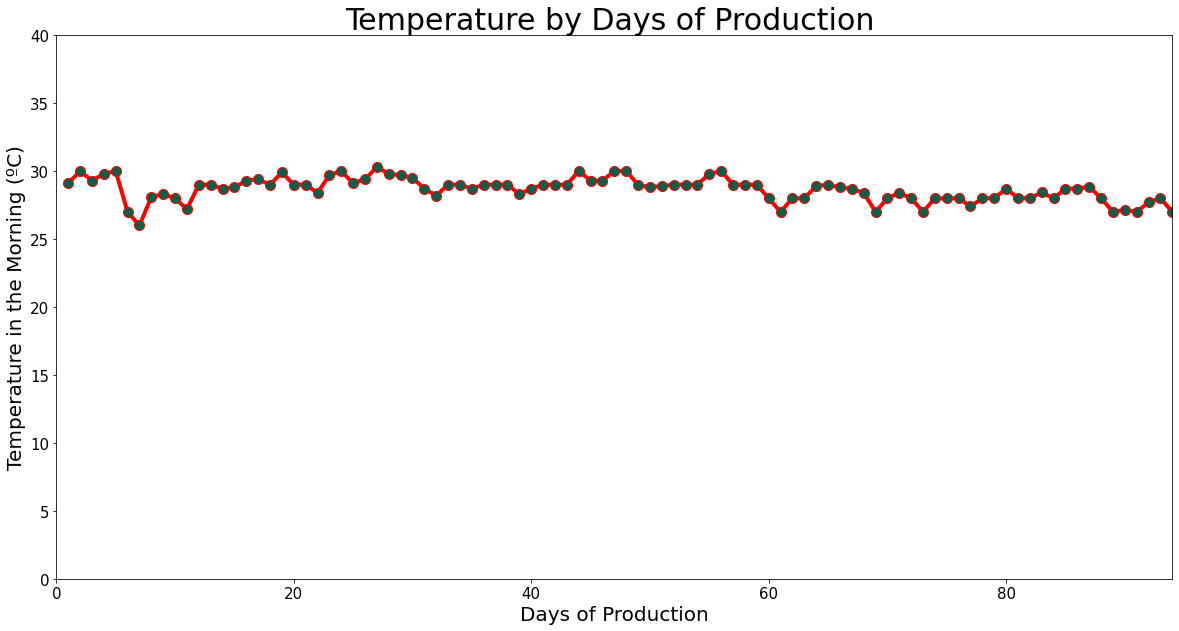

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20,10))
plt.plot('Days of production', 'Temperature in the Morning', data=temp_morn, marker='o', markerfacecolor='#0D5D47', markersize=10, color='red', linewidth=4)


xs=temp_morn['Days of production']
ys=temp_morn['Temperature in the Morning']
# for x,y in zip(xs,ys):

#     label = "{:.1f}".format(y)

#     plt.annotate(label, # this is the text
#                  (x,y), # this is the point to label
#                  rotation=0,
#                  textcoords="offset points", color='#0D5D47',# how to position the text
#                  xytext=(0,11), fontsize=12,# distance from text to points (x,y)
#                  ha='center') # horizontal alignment can be left, right or center



#Add some text for labels, title and custom x-axis tick labels, etc.
plt.ylabel('Temperature in the Morning (ºC)', fontsize=20)
plt.xlabel('Days of Production',fontsize=20)
ax.set_title('Temperature by Days of Production ', fontsize=30)
ax.set_ylim(ymin=0, ymax=40)
ax.set_xlim(xmin=0, xmax=94)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

In [ ]:
df1.groupby('Pond Identifier')['Temperature in the Morning'].mean()

Pond Identifier
A1      28.818182
A2      28.670213
A3      28.870130
A4      28.585106
A5      28.617021
A6      28.648936
A7      28.638298
A8      28.831169
A9      28.734043
AA10    28.595745
Name: Temperature in the Morning, dtype: float64

The average of temperature in the morning distributed in 28ºC uniformly.

In [ ]:
df1.groupby('Pond Identifier')['TAN'].mean()

Pond Identifier
A1      0.552000
A2      0.805615
A3      0.766909
A4      0.977577
A5      0.773885
A6      0.693500
A7      0.738154
A8      0.553273
A9      0.554654
AA10    0.892462
Name: TAN, dtype: float64

In [ ]:
tan_min = pd.DataFrame(df1.groupby(by='Pond Identifier')['TAN'].min())
tan_min = tan_min.reset_index(inplace=False)
#tan_min

In [ ]:
tan_max = pd.DataFrame(df1.groupby(by='Pond Identifier')['TAN'].max())
tan_max = tan_max.reset_index(inplace=False)
#tan_max

In [ ]:
df1.agg({'TAN': ['min', 'max']})

,TAN
min,0.113
max,2.774


In [ ]:
tan_avg = df1.groupby('Pond Identifier')['TAN'].mean().round(2)
tan_avg = tan_avg.reset_index(inplace=False)
#tan_avg

In [ ]:
tan_std = df1.groupby('Pond Identifier')['TAN'].std().round(2)
tan_std = tan_std.reset_index(inplace=False)
#tan_std

In [ ]:
tan1 = pd.merge(tan_avg, tan_std, on='Pond Identifier', how='left')
tan1 = tan1.rename(columns = {'TAN_x':'mean'})

In [ ]:
tan2 = pd.merge(tan1, tan_min, on='Pond Identifier', how='left')
tan2 = tan2.rename(columns = {'TAN_y':'stdev'})

In [ ]:
tan_merge = pd.merge(tan2, tan_max, on='Pond Identifier', how='left')
tan_merge = tan_merge.rename(columns = {'TAN_x':'min', 'TAN_y':'max'})

In [ ]:
# tan_merge

In [ ]:
gab = []
for i in tan_merge['mean']:
  mean = str(i) + ' ± '
  for j in tan_merge['stdev']:
      gab.append(mean +str(j))


In [ ]:
gab10 = gab[0:101:11]

In [ ]:
tan_merge['mean ± std'] = gab10

In [ ]:
#tan_merge.drop(['mean', 'stdev'], axis=1)

In [ ]:
#define list of column names
name_order = ['Pond Identifier','mean ± std','min','max']
tan_merge = tan_merge[name_order]
#tan_merge

In [ ]:
df1['Pond Identifier'].unique()

array(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'AA10'],
      dtype=object)

In [ ]:
df1['Days of production'].unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
       40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52.,
       53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64., 65.,
       66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77., 78.,
       79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90., 91.,
       92., 93., 94.])

There are 10 unique ponds in the shirmp culture and number of production days is 94 days of each pond.

In [ ]:
df1['Temperature in the Morning'].unique()

array([29., 30., 27., 26., 28., 31.])

In [ ]:
df1['Temperature in the Afternoon'].unique()

array([30.0, 32.0, 33.0, 27.0, 29.0, 31.0, '-', 28.0], dtype=object)

There's no missing value, but there's inappropriate (-) value in the variable of temperature. Let's check and how can we handle it?

In [ ]:
df1[df1 == '-'].count()

Days of production               0
Pond Identifier                  0
Temperature in the Morning       0
Temperature in the Afternoon     3
Temperature in the Evening       3
Feed per day                    85
TAN                              0
Phosphate                        0
Phytoplankton                    0
dtype: int64

In [ ]:
df1[df1['Temperature in the Afternoon'] == '-']

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
76,77.0,A1,27.0,-,-,-,NaN,NaN,NaN
247,77.0,A3,28.0,-,-,5.0,NaN,NaN,NaN
700,77.0,A8,27.0,-,-,-,NaN,NaN,NaN


We decide to takeout all values on the ponds A1, A3, and A8 from our analysis since they have inconsistent data records (77 samples) while others have 94 data records.

*Assumption: all ponds except A1, A3, A8 have homogen condition which have the same dimension and treatment.*

In [ ]:
df1['Temperature in the Evening'].unique()

array([29.0, 31.0, 28.0, 27.0, 30.0, '-', 32.0], dtype=object)

In [ ]:
df1[df1['Temperature in the Evening'] == '-']

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
76,77.0,A1,27.0,-,-,-,NaN,NaN,NaN
247,77.0,A3,28.0,-,-,5.0,NaN,NaN,NaN
700,77.0,A8,27.0,-,-,-,NaN,NaN,NaN


In [ ]:
df1[df1['Days of production'] == 77]

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
76,77.0,A1,27.0,-,-,-,NaN,NaN,NaN
153,77.0,A2,28.0,29.0,29.0,5.0,NaN,NaN,NaN
247,77.0,A3,28.0,-,-,5.0,NaN,NaN,NaN
324,77.0,A4,27.0,29.0,29.0,5.0,NaN,NaN,NaN
418,77.0,A5,28.0,29.0,29.0,5.0,NaN,NaN,NaN
512,77.0,A6,27.0,29.0,29.0,5.0,NaN,NaN,NaN
606,77.0,A7,27.0,29.0,29.0,5.0,NaN,NaN,NaN
700,77.0,A8,27.0,-,-,-,NaN,NaN,NaN
777,77.0,A9,28.0,29.0,29.0,5.0,NaN,NaN,NaN
871,77.0,AA10,27.0,29.0,29.0,5.0,NaN,NaN,NaN


Days of production (77) in each pond have the same temperature (29ºC). Hence, we would change the sign (-) in the afternoon and evening temperature with 29.

In [ ]:
#replace "-" with 29
df1['Temperature in the Afternoon'] = df1['Temperature in the Afternoon'].replace(['-'],29)
df1['Temperature in the Evening'] = df1['Temperature in the Evening'].replace(['-'],29)

In [ ]:
#Average of temperature in the morning, afternoon, and evening
temp_avg = pd.DataFrame(df1.groupby('Days of production')['Temperature in the Morning', 'Temperature in the Afternoon', 'Temperature in the Evening'].mean()).round(2)
temp_avg = temp_avg.reset_index(inplace=False)
temp_avg.head()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  


,Days of production,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening
0,1.0,29.1,30.1,29.7
1,2.0,30.0,32.0,29.1
2,3.0,29.3,32.1,31.0
3,4.0,29.8,32.1,30.9
4,5.0,30.0,30.0,27.9


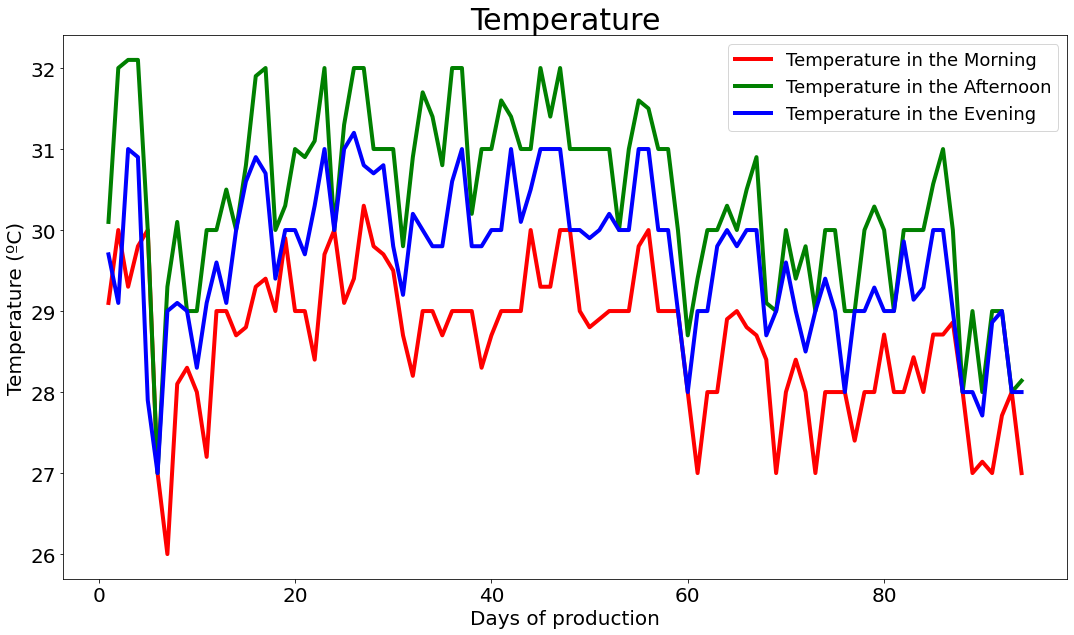

In [ ]:
fig, ax = plt.subplots(figsize=(18,10))
plt.plot('Days of production', 'Temperature in the Morning', data=temp_avg, color='red', linewidth=4)
plt.plot('Days of production', 'Temperature in the Afternoon', data=temp_avg, color='g', linewidth=4)
plt.plot('Days of production', 'Temperature in the Evening', data=temp_avg, color='b', linewidth=4)


#Add some text for labels, title and custom x-axis tick labels, etc.
plt.ylabel('Temperature (ºC)', fontsize=20)
plt.xlabel('Days of production',fontsize=20)
ax.set_title('Temperature', fontsize=30)
# ax.set_ylim(ymin=0, ymax=40)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.legend(fontsize=20)
plt.legend(fontsize=18)

From the graph above, we knew that temperature level (ºC) : **Afternoon > Evening > Morning** .

In [ ]:
df1['Feed per day'].unique()

array([3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5,
       11.0, 11.5, 12.0, 12.5, 14.0, 18.0, 19.0, 20.5, 21.5, 23.0, 24.0,
       25.5, 26.5, '-', 21.0, 22.0, 25.0, 26.0, 27.0, 28.5, 28.0, 30.0,
       32.0, 34.0, 29.0, 31.0, 35.0, 36.0, 33.0, 37.5, 40.0, 42.0, 44.0,
       45.0, 46.0, 50.0, 52.0, 54.0, 37.0, 38.0, 48.5, 48.0, 56.0, 58.0,
       60.0, 39.0, 13.5, 20.0, 6.5, 13.0, 17.0, 22.5, 23.5, 41.0, 43.0,
       62.0, 64.0], dtype=object)

### 2.2.3 Handling missing value ("-")

In [ ]:
df1[df1['Feed per day'] == '-'].groupby('Pond Identifier')['Days of production'].count()

Pond Identifier
A1       9
A2       7
A3       6
A4       7
A5       7
A6       9
A7       8
A8      11
A9      12
AA10     9
Name: Days of production, dtype: int64

In [ ]:
feed_a2 = df1[(df1['Feed per day'] == '-') & (df1['Pond Identifier'] == 'A2')]
feed_a2

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
108,32.0,A2,28.0,31.0,30.0,-,NaN,NaN,NaN
118,42.0,A2,29.0,32.0,31.0,-,NaN,NaN,NaN
119,43.0,A2,29.0,31.0,30.0,-,NaN,NaN,NaN
127,51.0,A2,29.0,31.0,30.0,-,NaN,NaN,NaN
141,65.0,A2,29.0,30.0,30.0,-,NaN,NaN,NaN
148,72.0,A2,28.0,30.0,29.0,-,NaN,NaN,NaN
162,86.0,A2,29.0,31.0,30.0,-,NaN,NaN,NaN


In [ ]:
df1[(df['Days of production'] == 49)  | (df['Days of production'] == 50) | (df['Days of production'] == 51)]

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
48,49.0,A1,29.0,31.0,30.0,26.0,NaN,NaN,NaN
49,50.0,A1,29.0,31.0,30.0,24.0,NaN,NaN,NaN
50,51.0,A1,29.0,31.0,30.0,-,NaN,NaN,NaN
125,49.0,A2,29.0,31.0,30.0,36.0,NaN,NaN,NaN
126,50.0,A2,29.0,31.0,30.0,24.0,NaN,NaN,NaN
127,51.0,A2,29.0,31.0,30.0,-,NaN,NaN,NaN
219,49.0,A3,29.0,31.0,30.0,38.0,NaN,NaN,NaN
220,50.0,A3,29.0,31.0,30.0,38.0,NaN,NaN,NaN
221,51.0,A3,29.0,31.0,30.0,-,NaN,NaN,NaN
296,49.0,A4,29.0,31.0,30.0,38.0,NaN,NaN,NaN


List of missing values (-) in each pond:

* 32 : ✅
* 42 : ✅
* 43 : ✅
* 50 : only A8, A9
* 51 : ✅
* 61 : only A6
* 62 : only A8
* 63 : only A1
* 65 : ✅
* 67 : only A1, A6, A6, A9, AA10
* 72 : ✅
* 77 : only A1, A8
* 79 : only A9
* 86 : except A1, A3, A8
* 88 : only A9
* 94 : only A9

note: ✅ : all ponds




Since the sample data on the day of production row (50) in some ponds look stray (8 kg of shrimp feed, while the other is 38 kg of shrimp feed), we decide to remove all (-) values in column feed per day.

### 2.2.4 Handling inconsistent grouped data records

How many row of TAN in each pond identifier?

In [ ]:
df1.groupby('Pond Identifier')['TAN'].count()

Pond Identifier
A1      22
A2      26
A3      22
A4      26
A5      26
A6      26
A7      26
A8      22
A9      26
AA10    26
Name: TAN, dtype: int64

A1, A3, and A8 have only 22 TAN records, while the others have 26 TAN records.

How many row of Days of production in each pond identifier?

In [ ]:
df1.groupby('Pond Identifier')['Days of production'].count()

Pond Identifier
A1      77
A2      94
A3      77
A4      94
A5      94
A6      94
A7      94
A8      77
A9      94
AA10    94
Name: Days of production, dtype: int64

The same case happens on A1, A3, and A8 which have 77 days of production different with the other ponds.

So, our next action, we would like to remove pond A1, A3, and A8 from our analysis.

In [ ]:
df1_TAN = pd.isnull(df1['TAN'])
df1[df1_TAN]

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
0,1.0,A1,29.0,30.0,29.0,3.5,NaN,NaN,NaN
1,2.0,A1,30.0,32.0,29.0,3.5,NaN,NaN,NaN
3,4.0,A1,29.0,32.0,31.0,4.0,NaN,NaN,NaN
4,5.0,A1,30.0,30.0,28.0,4.5,NaN,NaN,NaN
6,7.0,A1,26.0,29.0,29.0,5.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
883,89.0,AA10,27.0,29.0,28.0,60.0,NaN,NaN,NaN
885,91.0,AA10,27.0,29.0,29.0,64.0,NaN,NaN,NaN
886,92.0,AA10,28.0,29.0,29.0,64.0,NaN,NaN,NaN
887,93.0,AA10,28.0,28.0,28.0,64.0,NaN,NaN,NaN


There are 641 rows missing values of TAN.

In [ ]:
df1_PO4 = pd.isnull(df1['Phosphate'])
df1[df1_PO4]

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
0,1.0,A1,29.0,30.0,29.0,3.5,NaN,NaN,NaN
1,2.0,A1,30.0,32.0,29.0,3.5,NaN,NaN,NaN
3,4.0,A1,29.0,32.0,31.0,4.0,NaN,NaN,NaN
4,5.0,A1,30.0,30.0,28.0,4.5,NaN,NaN,NaN
6,7.0,A1,26.0,29.0,29.0,5.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
883,89.0,AA10,27.0,29.0,28.0,60.0,NaN,NaN,NaN
885,91.0,AA10,27.0,29.0,29.0,64.0,NaN,NaN,NaN
886,92.0,AA10,28.0,29.0,29.0,64.0,NaN,NaN,NaN
887,93.0,AA10,28.0,28.0,28.0,64.0,NaN,NaN,NaN


There are 641 rows missing values of Phosphate.

In [ ]:
df1_pp = pd.isnull(df1['Phytoplankton'])
df1[df1_pp]

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
0,1.0,A1,29.0,30.0,29.0,3.5,NaN,NaN,NaN
1,2.0,A1,30.0,32.0,29.0,3.5,NaN,NaN,NaN
3,4.0,A1,29.0,32.0,31.0,4.0,NaN,NaN,NaN
4,5.0,A1,30.0,30.0,28.0,4.5,NaN,NaN,NaN
6,7.0,A1,26.0,29.0,29.0,5.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
883,89.0,AA10,27.0,29.0,28.0,60.0,NaN,NaN,NaN
885,91.0,AA10,27.0,29.0,29.0,64.0,NaN,NaN,NaN
886,92.0,AA10,28.0,29.0,29.0,64.0,NaN,NaN,NaN
887,93.0,AA10,28.0,28.0,28.0,64.0,NaN,NaN,NaN


There are 641 rows missing values of Phytoplankton.

In [ ]:
#cek data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Days of production                889 non-null    float64
 1   Pond Identifier                   889 non-null    object 
 2   Temperature in the Morning        889 non-null    float64
 3   Temperature n the Afternoon       889 non-null    object 
 4   Temperature in the Evening        889 non-null    object 
 5   Feed per day (kg of shrimp feed)  889 non-null    object 
 6   TAN ppm                           248 non-null    float64
 7   Phosphate ppm                     248 non-null    float64
 8   Phytoplankton cells/ml            248 non-null    float64
dtypes: float64(5), object(4)
memory usage: 62.6+ KB


In [ ]:
#drop - value
for x in df1:
  df1.drop(df1.loc[df1[x]=='-'].index, inplace=True)

In [ ]:
#drop A1 A3 A8
indexPond = df1[(df1['Pond Identifier'] == 'A1') | (df1['Pond Identifier'] == 'A3') | (df1['Pond Identifier'] == 'A8')].index
df1.drop(indexPond, inplace = True)
df1.head()

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
77,1.0,A2,29.0,30.0,29.0,3.5,NaN,NaN,NaN
78,2.0,A2,30.0,32.0,29.0,3.5,NaN,NaN,NaN
79,3.0,A2,29.0,32.0,31.0,4.0,0.979,0.072,2500.0
80,4.0,A2,30.0,32.0,31.0,4.0,NaN,NaN,NaN
81,5.0,A2,30.0,30.0,28.0,4.5,NaN,NaN,NaN


In [ ]:
df1.groupby('Pond Identifier')['Days of production'].count()

Pond Identifier
A2      87
A4      87
A5      87
A6      85
A7      86
A9      82
AA10    85
Name: Days of production, dtype: int64

In [ ]:
#check missing values with sign (-)
df1[df1['Feed per day'] == '-']

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton


OK there's no "-" value anymore.

### 2.2.5 Handling missing values (NaN)

In [ ]:
#drop missing values
df1 = df1.dropna()

In [ ]:
df1.groupby('Pond Identifier')['Days of production'].count()

Pond Identifier
A2      26
A4      26
A5      26
A6      26
A7      26
A9      26
AA10    26
Name: Days of production, dtype: int64

In [ ]:
params_mean = df1.groupby('Pond Identifier')[['TAN','Phosphate', 'Phytoplankton']].mean()
# table_params

### 2.2.5 Data type conversion

Some variables probably don't have a proper data type. To ensure that all have correct data types. We need to check the data type, then we convert with a proper data type once it's wrong.

In [ ]:
df1['Temperature in the Morning'] = df1['Temperature in the Morning'].astype('int')
df1['Temperature in the Afternoon'] = df1['Temperature in the Afternoon'].astype('int')
df1['Temperature in the Evening'] = df1['Temperature in the Evening'].astype('int')
df1['Feed per day'] = df1['Feed per day'].astype('float')
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 182 entries, 79 to 884
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Days of production            182 non-null    float64
 1   Pond Identifier               182 non-null    object 
 2   Temperature in the Morning    182 non-null    int64  
 3   Temperature in the Afternoon  182 non-null    int64  
 4   Temperature in the Evening    182 non-null    int64  
 5   Feed per day                  182 non-null    float64
 6   TAN                           182 non-null    float64
 7   Phosphate                     182 non-null    float64
 8   Phytoplankton                 182 non-null    float64
dtypes: float64(5), int64(3), object(1)
memory usage: 14.2+ KB


In [ ]:
table_params = df1.groupby('Pond Identifier')[['Temperature in the Morning',	'Temperature in the Afternoon',	'Temperature in the Evening',
                                               'Feed per day','TAN','Phosphate', 'Phytoplankton']].mean()
# table_params

In [ ]:
df1.shape

(182, 9)

In [ ]:
df1.head()

,Days of production,Pond Identifier,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
79,3.0,A2,29,32,31,4.0,0.979,0.072,2500.0
82,6.0,A2,27,27,27,4.5,1.065,0.018,3000.0
86,10.0,A2,28,29,29,7.0,1.405,0.092,4000.0
89,13.0,A2,29,30,29,8.5,0.965,0.050,5000.0
93,17.0,A2,30,32,31,10.5,0.813,0.059,4000.0


In [ ]:
#process of data tabulation
tan_avg1 = df1.groupby('Pond Identifier')['TAN'].mean().round(3).reset_index(inplace=False)
tan_std1 = df1.groupby('Pond Identifier')['TAN'].std().round(3).reset_index(inplace=False)
tan_min1 = df1.groupby('Pond Identifier')['TAN'].min().round(3).reset_index(inplace=False)
tan_max1 = df1.groupby('Pond Identifier')['TAN'].max().round(3).reset_index(inplace=False)

In [ ]:
#merging stat descriptive data of the parameters
tan1 = pd.merge(tan_avg1, tan_std1, on='Pond Identifier', how='left')
tan1 = tan1.rename(columns = {'TAN_x':'mean'})

tan2 = pd.merge(tan1, tan_min1, on='Pond Identifier', how='left')
tan2 = tan2.rename(columns = {'TAN_y':'stdev'})

tan_merge = pd.merge(tan2, tan_max1, on='Pond Identifier', how='left')
tan_merge = tan_merge.rename(columns = {'TAN_x':'min', 'TAN_y':'max'})

In [ ]:
#mean tan
gab = []
for i in tan_merge['mean']:
  mean = str(i) + ' ± '
  for j in tan_merge['stdev']:
      gab.append(mean +str(j))

gab7 = gab[0:50:8]
tan_merge['mean ± std'] = gab7

#range tan
range = []
for i in tan_merge['min']:
  min = str(i) + ' - '
  for j in tan_merge['max']:
      range.append(min +str(j))

range7 = range[0:50:8]
tan_merge['range'] = range7


In [ ]:
#TAN
tan_merge = tan_merge.drop(['mean', 'stdev', 'min', 'max'], axis=1)

In [ ]:
#process of data tabulation (Phosphate)
po4_avg = df1.groupby('Pond Identifier')['Phosphate'].mean().round(3).reset_index(inplace=False)
po4_std = df1.groupby('Pond Identifier')['Phosphate'].std().round(3).reset_index(inplace=False)
po4_min = df1.groupby('Pond Identifier')['Phosphate'].min().round(3).reset_index(inplace=False)
po4_max = df1.groupby('Pond Identifier')['Phosphate'].max().round(3).reset_index(inplace=False)

In [ ]:
#merging stat descriptive of Phosphate parameter
po4_1 = pd.merge(po4_avg, po4_std, on='Pond Identifier', how='left')
po4_1 = po4_1.rename(columns = {'Phosphate_x':'mean'})

po4_2 = pd.merge(po4_1, po4_min, on='Pond Identifier', how='left')
po4_2 = po4_2.rename(columns = {'Phosphate_y':'stdev'})

po4_merge = pd.merge(po4_2, po4_max, on='Pond Identifier', how='left')
po4_merge = po4_merge.rename(columns = {'Phosphate_x':'min', 'Phosphate_y':'max'})

In [ ]:
#mean PO4-
gab = []
for i in po4_merge['mean']:
  mean = str(i) + ' ± '
  for j in po4_merge['stdev']:
      gab.append(mean +str(j))

gab7 = gab[0:50:8]
po4_merge['mean ± std'] = gab7

#range PO4-
range = []
for i in po4_merge['min']:
  min = str(i) + ' - '
  for j in po4_merge['max']:
      range.append(min +str(j))

range7 = range[0:50:8]
po4_merge['range'] = range7


In [ ]:
#Phosphate
po4_merge = po4_merge.drop(['mean', 'stdev', 'min', 'max'], axis=1)

In [ ]:
#process of data tabulation (Phytoplankton)
pp_avg = df1.groupby('Pond Identifier')['Phytoplankton'].mean().round(3).reset_index(inplace=False)
pp_std = df1.groupby('Pond Identifier')['Phytoplankton'].std().round(3).reset_index(inplace=False)
pp_min = df1.groupby('Pond Identifier')['Phytoplankton'].min().round(3).reset_index(inplace=False)
pp_max = df1.groupby('Pond Identifier')['Phytoplankton'].max().round(3).reset_index(inplace=False)

In [ ]:
#merging stat descriptive of Phytoplankton
pp1 = pd.merge(pp_avg, pp_std, on='Pond Identifier', how='left')
pp1 = pp1.rename(columns = {'Phytoplankton_x':'mean'})

pp2 = pd.merge(pp1, pp_min, on='Pond Identifier', how='left')
pp2 = pp2.rename(columns = {'Phytoplankton_y':'stdev'})

pp_merge = pd.merge(pp2, pp_max, on='Pond Identifier', how='left')
pp_merge = pp_merge.rename(columns = {'Phytoplankton_x':'min', 'Phytoplankton_y':'max'})

In [ ]:
#mean Phytoplankton
gab = []
for i in pp_merge['mean']:
  mean = str(i) + ' ± '
  for j in pp_merge['stdev']:
      gab.append(mean +str(j))

gab7 = gab[0:50:8]
pp_merge['mean ± std'] = gab7

#range Phytoplankton
range = []
for i in pp_merge['min']:
  min = str(i) + ' - '
  for j in pp_merge['max']:
      range.append(min +str(j))

range7 = range[0:50:8]
pp_merge['range'] = range7


In [ ]:
#Phytoplankton density
pp_merge = pp_merge.drop(['mean', 'stdev', 'min', 'max'], axis=1)

In [ ]:
#Rename column
q_merge = tan_merge.merge(po4_merge, on='Pond Identifier', how='left')
q_merge = q_merge.rename(columns = {'mean ± std_x':'TAN mean ± std', 'range_x':'TAN range',
                                    'mean ± std_y':'Phosphate mean ± std', 'range_y':'Phosphate range'})
param_merge = q_merge.merge(pp_merge, on='Pond Identifier', how='left')
param_merge = param_merge.rename(columns = {'mean ± std':'Phytoplankton mean ± std', 'range':'Phytoplankton range'})

In [ ]:
#transpose column
param_merge_T = param_merge.T

In [ ]:
#change column index becomes column name
param_merge_T.columns = param_merge_T.iloc[0]

In [ ]:
#drop row index
params = param_merge_T.drop(param_merge_T.index[0])

In [ ]:
#param_merge_T.iloc[pd.RangeIndex(len(param_merge_T)).drop(0)]

In [ ]:
# param_merge_T.rename(columns=param_merge_T.iloc[0]).drop('Pond Identifier')

In [ ]:
params.index.rename('Quality Parameters')

Index(['TAN mean ± std', 'TAN range', 'Phosphate mean ± std',
       'Phosphate range', 'Phytoplankton mean ± std', 'Phytoplankton range'],
      dtype='object', name='Quality Parameters')

In [ ]:
params.columns

Index(['A2', 'A4', 'A5', 'A6', 'A7', 'A9', 'AA10'], dtype='object', name='Pond Identifier')

In [ ]:
# q_param = pd.DataFrame(['Phytoplanton'])
# # pd.concat([q_param,pp_merge])
# pd.concat([q_param,pp_merge]).set_index(0)

## 2.3 Analysis

### 2.3.1 Descriptive Statistics

In [ ]:
temp_mean = ((df1['Temperature in the Morning'].mean()+ df1['Temperature in the Afternoon'].mean() + df1['Temperature in the Evening'].mean())/ 3).round(2)
print('The temperature average value was ', temp_mean, 'ºC')

The temperature average value was  29.49 ºC


In [ ]:
#The average value of water quality parameters during the shrimp culture period
df1.agg({'Temperature in the Morning': ['mean', 'std', 'min', 'max'],
         'Temperature in the Afternoon': ['mean','std', 'min', 'max'],
         'Temperature in the Evening':['mean','std', 'min', 'max'],
         'TAN':['mean','std', 'min', 'max'],
         'Phosphate':['mean','std', 'min', 'max'],
         'Phytoplankton':['mean','std', 'min', 'max']})

,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,TAN,Phosphate,Phytoplankton
mean,28.725275,30.269231,29.478022,0.776549,0.189121,10007.142857
std,0.964175,1.282711,1.049631,0.524966,0.114997,4824.156935
min,27.000000,27.000000,27.000000,0.113000,0.018000,2000.000000
max,31.000000,32.000000,31.000000,2.774000,0.581000,23500.000000



* The temperature average value was 29.49ºC, where 28.7ºC, 30.3ºC and 29.5ºC were recorded in the morning, afternoon, and evening, respectively.

* The average temperature value obtained in the study was 29.49ºC, which is optimum for shrimp growth. This was in accordance with the results of Wyban et al (1995), where the optimal value was at 27–30ºC. This is an important influence on the fluctuations in pond productivity (Prapaiwong & Boyd 2012).

* The Phytoplankton density had an average value
of 10007.143 cell/ml, where morning-evening fluctuations ranged from 2000 to 23500 cell/ml.


#### 2.3.1.1 The average value of water quality parameters during the shrimp culture period

In [ ]:
#The average value of water quality parameters during the shrimp culture period by pond identifier
params

Pond Identifier,A2,A4,A5,A6,A7,A9,AA10
TAN mean ± std,0.806 ± 0.673,0.978 ± 0.596,0.774 ± 0.511,0.694 ± 0.429,0.738 ± 0.311,0.555 ± 0.394,0.892 ± 0.611
TAN range,0.113 - 2.774,0.131 - 2.694,0.173 - 1.912,0.144 - 1.81,0.265 - 1.901,0.179 - 1.63,0.136 - 2.633
Phosphate mean ± std,0.182 ± 0.115,0.26 ± 0.175,0.185 ± 0.084,0.158 ± 0.091,0.185 ± 0.093,0.156 ± 0.076,0.197 ± 0.12
Phosphate range,0.018 - 0.461,0.029 - 0.581,0.063 - 0.403,0.038 - 0.401,0.038 - 0.362,0.04 - 0.319,0.026 - 0.517
Phytoplankton mean ± std,9461.538 ± 4575.856,9911.538 ± 4818.243,10023.077 ± 4774.709,10076.923 ± 4881.992,9334.615 ± 4287.558,10096.154 ± 4707.482,11146.154 ± 5917.042
Phytoplankton range,2500.0 - 19000.0,3000.0 - 21500.0,2500.0 - 18000.0,2500.0 - 21000.0,2500.0 - 17500.0,2000.0 - 18000.0,2000.0 - 23500.0




* The average phytoplankton as a biological parameter was 10007.143
cell/ml, within the range of 2000 and 23500 cell/ml. Furthermore, the values of phytoplankton density were different in each pond, due to the differences in the input of nutrients and, therefore, plankton structure and density were influenced by the tropic status of the waters, because of the accumulating nutrient (Case et al 2008). In addition, a higher input of feed per day affects the rate of decomposition by microorganisms.  Thus, there is an accumulation of waste from leftover feed, feces, plankton lysis and other detritus in the pond sediments (Lemonnier et al 2010).
* The TAN level showed an inappropriate range (0.11 - 2.77 ppm), where the recommendation for intensive shrimp culture is < 0.1 ppm (Edhy et al 2010).
* The Phosphate level was slightly in an appropriate range, with the average 0.189 ppm, within the range of 0.018 and 0.581 ppm. The amounts of phosphates tend to meet the recommendation, which is < 0.2 ppm (Bhatnagar & Devi 2013).

Nitrogen plays an important role in intensive culture systems due to its dual role as a nutrient and toxicant. Phosphorus is one of the most important nutrient parameters for phytoplankton growth in marine environments (MA et al 2012). In shrimp aquaculture, ammonia is also one of the main water pollutants and in fact the main limiting factor that causes rapid increase in shrimp mortality. Meanwhile, the stable and optimum temperature could increase shrimp metabolism and spead up the TAN degradation (Mingming et al 2020).  It is possible to state that the concentration levels of TAN, Phosphate and temperature during the shrimp cultivation period were within the optimum range.



### 2.3.2 Correlation Analysis

In [ ]:
#drop unnecessary columns
df_corr = df1.drop(columns=['Pond Identifier','Days of production'])
df_corr.head()

,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
79,29,32,31,4.0,0.979,0.072,2500.0
82,27,27,27,4.5,1.065,0.018,3000.0
86,28,29,29,7.0,1.405,0.092,4000.0
89,29,30,29,8.5,0.965,0.050,5000.0
93,30,32,31,10.5,0.813,0.059,4000.0


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  after removing the cwd from sys.path.


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 <a list of 7 Text major ticklabel objects>)

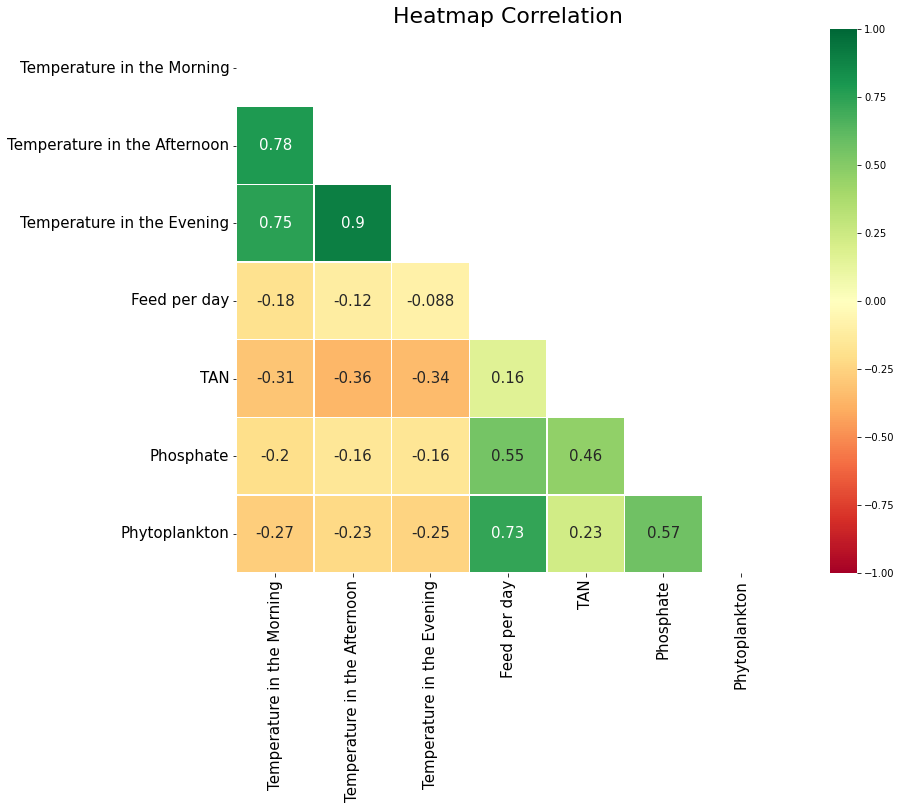

In [ ]:
import seaborn as sns
corr = df_corr.corr()
# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(18, 10))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220,10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,cmap="RdYlGn", vmin=-1, vmax=1, center=0, cbar=True, annot =True,
            square=True, linewidths=.5, annot_kws={"size": 15})
plt.xticks(rotation=90, fontsize=15)
plt.title('Heatmap Correlation', fontsize=22)
plt.yticks(fontsize=15)

The relationship between feed per day and other quality parameters of water.

In [ ]:
df_corr.corr()

,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening,Feed per day,TAN,Phosphate,Phytoplankton
Temperature in the Morning,1.000000,0.783824,0.752830,-0.180138,-0.305579,-0.198815,-0.271939
Temperature in the Afternoon,0.783824,1.000000,0.901038,-0.116156,-0.361900,-0.156109,-0.225664
Temperature in the Evening,0.752830,0.901038,1.000000,-0.087964,-0.344552,-0.161370,-0.248357
Feed per day,-0.180138,-0.116156,-0.087964,1.000000,0.159794,0.548122,0.728992
TAN,-0.305579,-0.361900,-0.344552,0.159794,1.000000,0.464566,0.232777
Phosphate,-0.198815,-0.156109,-0.161370,0.548122,0.464566,1.000000,0.569095
Phytoplankton,-0.271939,-0.225664,-0.248357,0.728992,0.232777,0.569095,1.000000


Based on the results of the correlation test, the concentration of TAN and Phosphate have fluctuation in values during shrimp culture.
* There is a positive correlation between feed per day and Phosphate (0.548)
* Feed per day has a positive correlation with Phytoplankton density (0.730)
* There's no significant relationship between feed per day and TAN (0.159)
* There's no significant relationship between temperature and all quality parameters. From the correlation test above, all temperature measurements indicate a weak negative correlation with TAN fluctuation. (Temperature in the morning, afternoon, evening, -0,306, -0.362, -0.345, respectively)


Meanwhile a change of TAN has indirect relationship due to fluctuation of Phosphate (0.465)

The effect of fluctuations in parameters of water on shrimp growth rates in ponds can be characterized by a regression analysis in the colaboratory cells below.



### 2.3.3 Regression Analysis

We would like to know the change of the parameters (TAN, Phosphate, & Phytoplankton) over time. We have a hypothesis that **feed per day** affected the concentration of parameters. Thus, we treat feed per day as dependent variable (y), and the quality parameter as independent variable (x). The relationship between feed per day and water quality parameter can be explained by scatter plot with regression line in the figure below.

In [ ]:
#Merging temperature measurement in one columnn by calculating the mean (I think this calculation in this cell is wrong method)
temp_merge = (df1['Temperature in the Morning']+df1['Temperature in the Afternoon'] +
              df1['Temperature in the Evening'])/3
#temp_merge

In [ ]:
#Merging temperature measurement in one columnn by calculating the mean
temp_group = pd.DataFrame(df1.groupby('Days of production')['Temperature in the Morning', 'Temperature in the Afternoon','Temperature in the Evening'].mean())
temp_group = temp_group.reset_index(inplace=False)
temp_group


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  


,Days of production,Temperature in the Morning,Temperature in the Afternoon,Temperature in the Evening
0,3.0,29.428571,32.000000,31.000000
1,6.0,27.000000,27.000000,27.000000
2,10.0,28.000000,29.000000,28.285714
3,13.0,29.000000,30.285714,29.142857
4,17.0,29.428571,32.000000,30.714286
5,20.0,29.000000,31.000000,30.000000
6,24.0,30.000000,30.000000,30.000000
7,27.0,30.285714,32.000000,30.714286
8,31.0,28.571429,29.714286,29.000000
9,34.0,29.000000,31.428571,29.714286


In [ ]:
temp_merge = ((temp_group['Temperature in the Morning']+temp_group['Temperature in the Afternoon'] +
             temp_group['Temperature in the Evening'])/3).round(2)
#temp_merge

In [ ]:
params_avg = pd.DataFrame(df1.groupby('Days of production')['Feed per day','TAN', 'Phosphate', 'Phytoplankton'].mean()).round(2)
params_avg = params_avg.reset_index(inplace=False)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  """Entry point for launching an IPython kernel.


In [ ]:
params_avg['Temperature'] = temp_merge

In [ ]:
# This is our final dataset after cleaned , next will be used for analysis
params_avg.head()

,Days of production,Feed per day,TAN,Phosphate,Phytoplankton,Temperature
0,3.0,4.00,0.73,0.07,2428.57,30.81
1,6.0,4.50,0.93,0.07,3428.57,27.00
2,10.0,6.93,0.64,0.07,4642.86,28.43
3,13.0,8.43,0.93,0.08,4000.00,29.48
4,17.0,10.43,1.12,0.13,3857.14,30.71


#### 2.3.3.1 Effect of feed per day on water quality parameter (Phosphate)

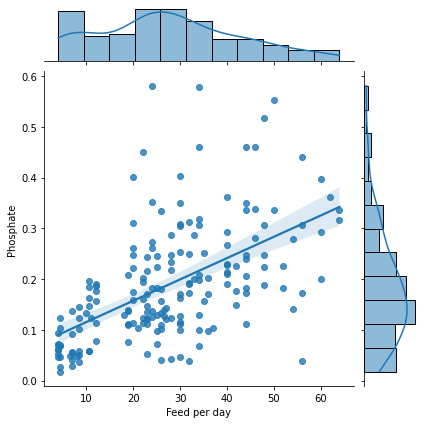

In [ ]:
import seaborn as sns
#create scatterplot with regression line & dist and confidence interval lines
sns.jointplot(x='Feed per day', y='Phosphate', data=df_corr, kind="reg")

The graph above showed the distribution of feed per day and water quality parameter (phosphate) have a positive relationship.  

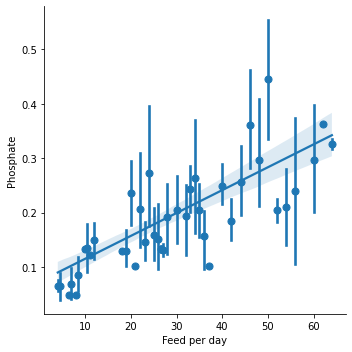

In [ ]:
#regression line with x estimator by mean
sns.lmplot(x='Feed per day', y='Phosphate', data=df_corr, x_estimator=np.mean)

In [ ]:
import statsmodels.api as sm

In [ ]:
#divide variables into x and y
x = df_corr['Feed per day']
y = df_corr['Phosphate']

In [ ]:
#Regression formula
X_stat = sm.add_constant(x)
reg = sm.OLS(y, X_stat).fit()
reg.summary()

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Phosphate   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     77.30
Date:                Mon, 05 Dec 2022   Prob (F-statistic):           1.16e-15
Time:                        09:19:47   Log-Likelihood:                 168.41
No. Observations:                 182   AIC:                            -332.8
Df Residuals:                     180   BIC:                            -326.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0734      0.015      4.898      0.000       0.044       0.103
Feed per day     0.0042      0.000      8.792      0.000       0.003       0.005
==============================================================================
Omnibus:                       46.410   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               98.487
Skew:                           1.164   Prob(JB):                     4.11e-22
Kurtosis:                       5.752   Cond. No.                         65.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Regression equation:**

Y = 0.0734 + 0.0042X

R-squared : 0.300

> It means that adjustion in feed per day in ponds affect phosphate concentration in about 30%,
while the other 70% is influenced by other factors.



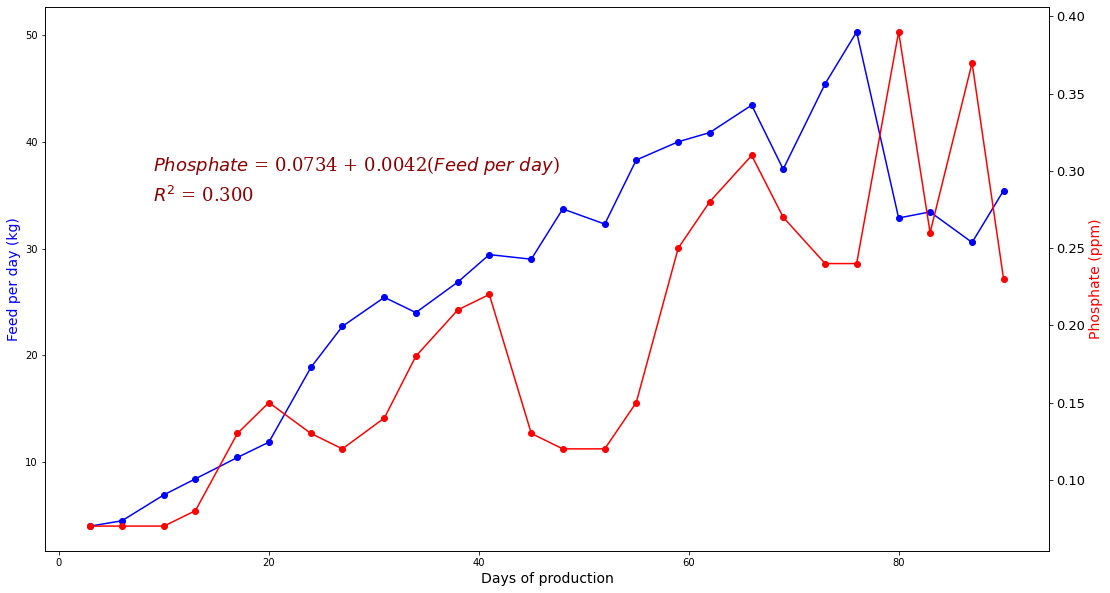

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
X = params_avg['Days of production']
y1 = params_avg['Feed per day']
y2 = params_avg['Phosphate']

font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 18,
        }

fig, ax1 = plt.subplots(figsize=(18,10))

ax2 = ax1.twinx()
ax1.plot(X, y1, 'b-',  marker="o")
ax2.plot(X, y2, 'r-',  marker="o")

ax1.set_xlabel('Days of production', fontsize=14)
ax1.set_ylabel('Feed per day (kg)', color='b', fontsize=14)
ax2.set_ylabel('Phosphate (ppm)', color='r', fontsize=14)

# ax.set_title('Title', fontsize=30)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.text(9, 0.3, r'$Phosphate$ = 0.0734 + 0.0042($Feed$ $per$ $day$)', fontdict=font)
plt.text(9, 0.28, r'${R^2}$ = 0.300', fontdict=font)

plt.show()

The graph above showed the effect of feed per day on water quality parameter (phosphate). Change of amount in feed per day had a linear relationship with Phosphate level.

#### 2.3.3.2 Effect of feed per day on water quality parameter (Phytoplankton)

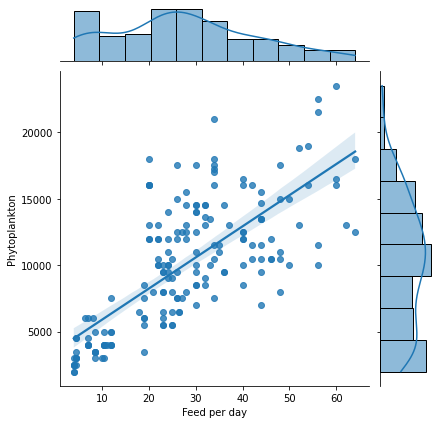

In [ ]:
#create scatterplot with regression line & dist and confidence interval lines
sns.jointplot(x='Feed per day', y='Phytoplankton', data=df_corr, kind="reg")

The graph above showed the dynamics of feed per day and water quality parameter (phytoplankton) have a close relationship on a shrimp culture.  

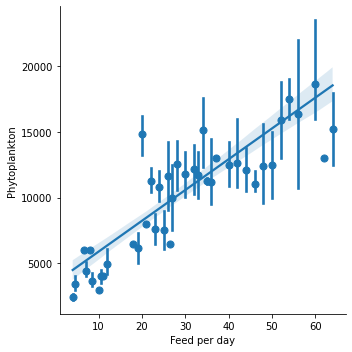

In [ ]:
#regression line with x estimator by mean
sns.lmplot(x='Feed per day', y='Phytoplankton', data=df_corr, x_estimator=np.mean)

In [ ]:
x = df_corr['Feed per day']
y = df_corr['Phytoplankton']

In [ ]:
#Regression formula
X_stat = sm.add_constant(x)
reg = sm.OLS(y, X_stat).fit()
reg.summary()

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Phytoplankton   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     204.1
Date:                Mon, 05 Dec 2022   Prob (F-statistic):           1.90e-31
Time:                        09:19:50   Log-Likelihood:                -1732.4
No. Observations:                 182   AIC:                             3469.
Df Residuals:                     180   BIC:                             3475.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         3549.5730    514.310      6.902      0.000    2534.721    4564.425
Feed per day   234.3525     16.402     14.288      0.000     201.987     266.717
==============================================================================
Omnibus:                       12.636   Durbin-Watson:                   0.868
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               13.541
Skew:                           0.665   Prob(JB):                      0.00115
Kurtosis:                       3.137   Cond. No.                         65.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Regression equation:**

y = 3549.573 + 234.353X

R-squared : 0.531

> It means that addition in feed per day in ponds affect Phytoplankton density in about 53.1%, while the other 46.9% is influenced by other factors.

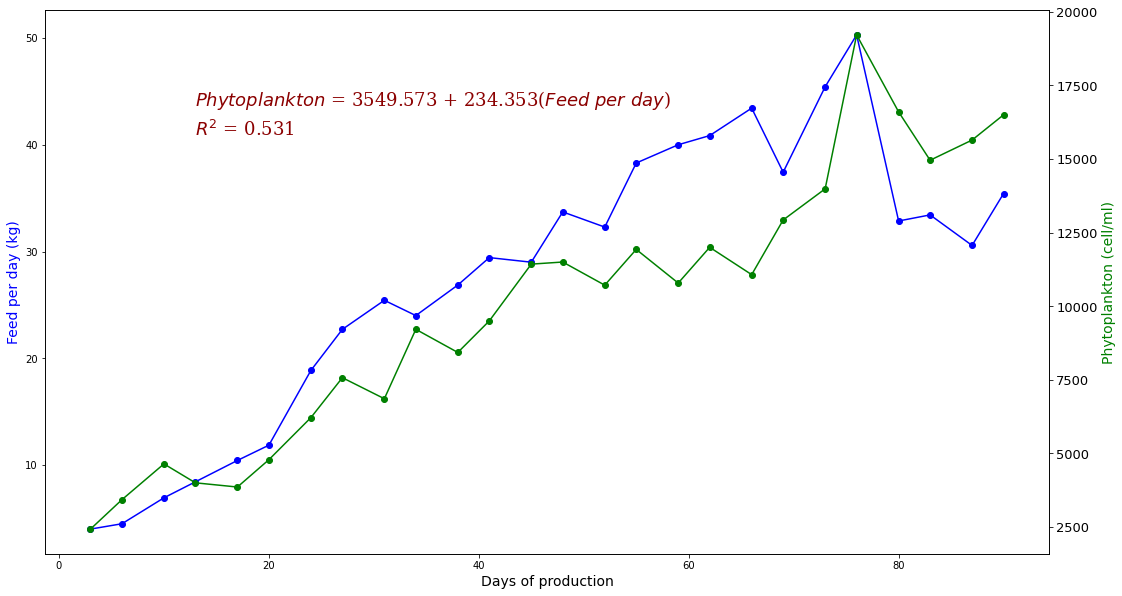

In [ ]:
X = params_avg['Days of production']
y1 = params_avg['Feed per day']
y2 = params_avg['Phytoplankton']

font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 18,
        }

fig, ax1 = plt.subplots(figsize=(18,10))

ax2 = ax1.twinx()
ax1.plot(X, y1, 'b-',  marker="o")
ax2.plot(X, y2, 'g-',  marker="o")

ax1.set_xlabel('Days of production', fontsize=14)
ax1.set_ylabel('Feed per day (kg)', color='b', fontsize=14)
ax2.set_ylabel('Phytoplankton (cell/ml)', color='g', fontsize=14)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
# set text
plt.text(13, 16800, r'$Phytoplankton$ = 3549.573 + 234.353($Feed$ $per$ $day$)', fontdict=font)
plt.text(13, 15800, r'${R^2}$ = 0.531', fontdict=font)
plt.show()

The graph above showed the effect of feed per day on water quality parameter (Phytoplankton density). Change of amount in feed per day had a linear relationship with Phytoplankton density.

#### 2.3.3.3 Effect of feed per day on water quality parameter (TAN)

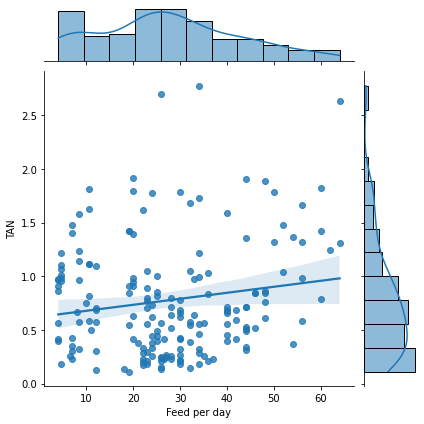

In [ ]:
import seaborn as sns
#create scatterplot with regression line & dist and confidence interval lines
sns.jointplot(x='Feed per day', y='TAN', data=df_corr, kind="reg")

The graph above showed the dynamics of feed per day and water quality parameter (TAN) have not significant relationship on a shrimp culture.

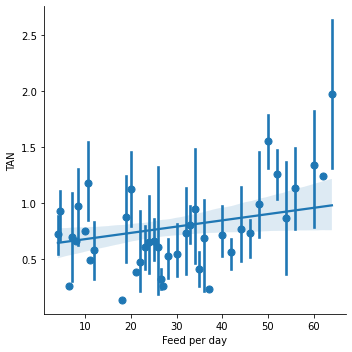

In [ ]:
#regression line with x estimator by mean
sns.lmplot(x='Feed per day', y='TAN', data=df_corr, x_estimator=np.mean)

In [ ]:
x = df_corr['Feed per day']
y = df_corr['TAN']

In [ ]:
#Regression formula
X_stat = sm.add_constant(x)
reg = sm.OLS(y, X_stat).fit()
reg.summary()

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    TAN   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     4.717
Date:                Mon, 05 Dec 2022   Prob (F-statistic):             0.0312
Time:                        09:19:53   Log-Likelihood:                -138.11
No. Observations:                 182   AIC:                             280.2
Df Residuals:                     180   BIC:                             286.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.6225      0.081      7.713      0.000       0.463       0.782
Feed per day     0.0056      0.003      2.172      0.031       0.001       0.011
==============================================================================
Omnibus:                       37.628   Durbin-Watson:                   0.782
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               55.218
Skew:                           1.166   Prob(JB):                     1.02e-12
Kurtosis:                       4.357   Cond. No.                         65.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

y = 0.6254 + 0.0055X

R-squared : 0.026

> It means that addition in feed per day in ponds affect TAN in about 2.6%, while the other 97.4% is influenced by other factors.

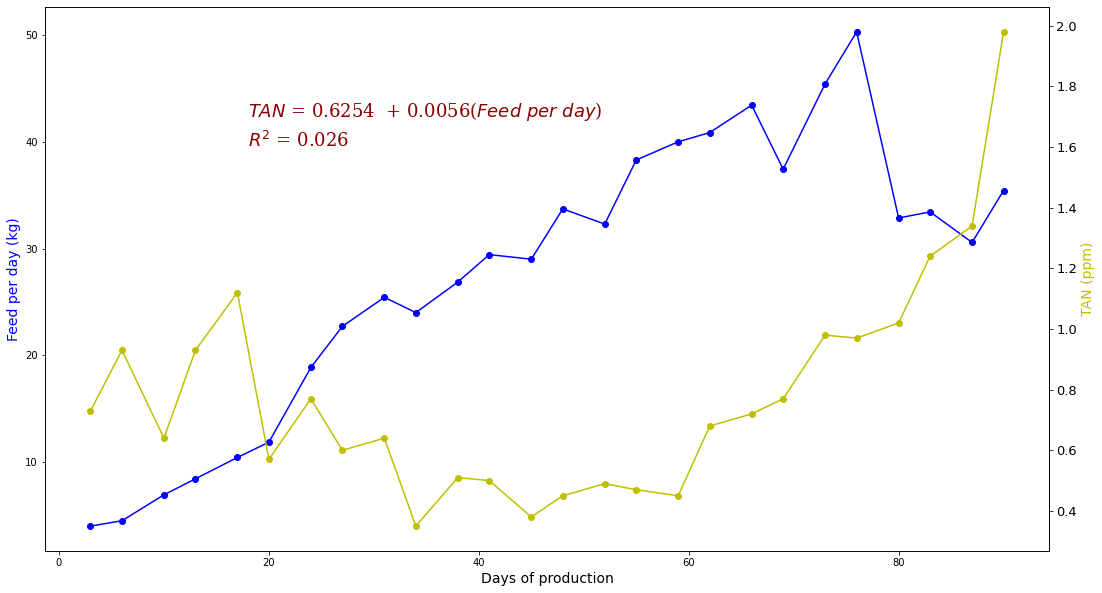

In [ ]:
X = params_avg['Days of production']
y1 = params_avg['Feed per day']
y2 = params_avg['TAN']

font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 18,
        }

fig, ax1 = plt.subplots(figsize=(18,10))

ax2 = ax1.twinx()
ax1.plot(X, y1, 'b-',  marker="o")
ax2.plot(X, y2, 'y-',  marker="o")

ax1.set_xlabel('Days of production', fontsize=14)
ax1.set_ylabel('Feed per day (kg)', color='b', fontsize=14)
ax2.set_ylabel('TAN (ppm)', color='y', fontsize=14)

# ax.set_title('Effect of peed per day on water quality parameter (TAN) ', fontsize=30)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
# ax1.legend(fontsize=15)
# ax2.legend(fontsize=15)
# plt.legend(fontsize=15)
# set text
plt.text(18, 1.7, r'$TAN$ = 0.6254  + 0.0056($Feed$ $per$ $day$)', fontdict=font)
plt.text(18, 1.6, r'${R^2}$ = 0.026', fontdict=font)
plt.show()
plt.show()

The graph above showed the effect of feed per day on water quality parameter (TAN). In this study, change of amount in feed per day had not a significant relationship with TAN.

#### 2.3.3.4 Effect of temperature on water quality parameter (TAN)

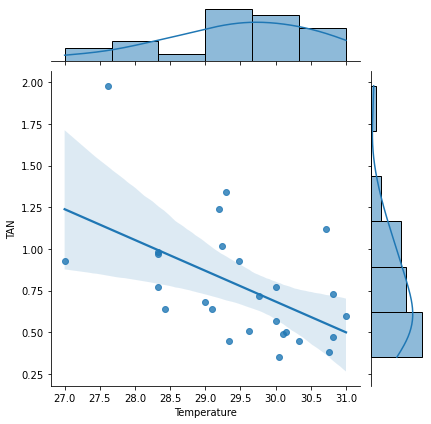

In [ ]:
import seaborn as sns
#create scatterplot with regression line & dist and confidence interval lines
sns.jointplot(x='Temperature', y='TAN', data=params_avg, kind="reg")

The graph above showed the dynamics of temperature and water quality parameter (TAN) have negative relationship on a shrimp culture.

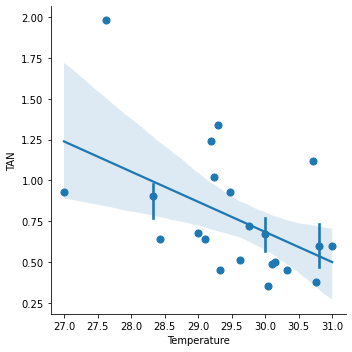

In [ ]:
#regression line with x estimator by mean
sns.lmplot(x='Temperature', y='TAN', data=params_avg, x_estimator=np.mean)

In [ ]:
x = params_avg['Temperature']
y = params_avg['TAN']

In [ ]:
#Regression formula
X_stat = sm.add_constant(x)
reg = sm.OLS(y, X_stat).fit()
reg.summary()

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    TAN   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.248
Method:                 Least Squares   F-statistic:                     9.250
Date:                Mon, 05 Dec 2022   Prob (F-statistic):            0.00562
Time:                        09:19:55   Log-Likelihood:                -5.7631
No. Observations:                  26   AIC:                             15.53
Df Residuals:                      24   BIC:                             18.04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           6.2288      1.793      3.474      0.002       2.528       9.930
Temperature    -0.1848      0.061     -3.041      0.006      -0.310      -0.059
==============================================================================
Omnibus:                        8.235   Durbin-Watson:                   0.741
Prob(Omnibus):                  0.016   Jarque-Bera (JB):                6.453
Skew:                           1.163   Prob(JB):                       0.0397
Kurtosis:                       3.741   Cond. No.                         859.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

y = 6.2301 - 0.1849X

R-squared : 0.278

> It means that adjustion in temperature in ponds decrease TAN level in about 27.8%, while the other 72.2% is influenced by other factors.

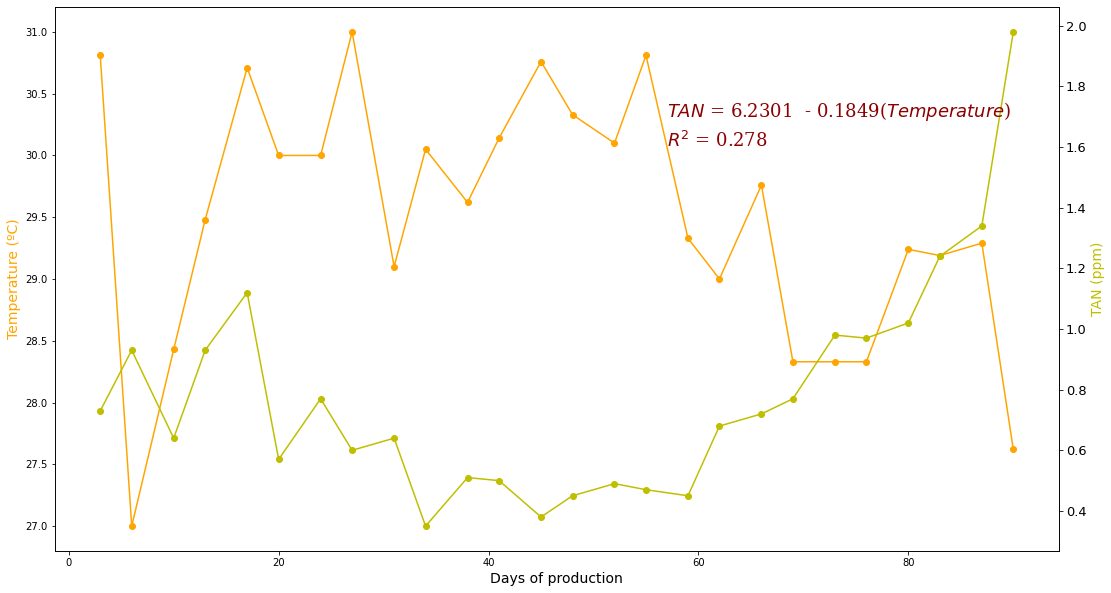

In [ ]:
X = params_avg['Days of production']
y1 = params_avg['Temperature']
y2 = params_avg['TAN']

font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 18,
        }

fig, ax1 = plt.subplots(figsize=(18,10))

ax2 = ax1.twinx()
ax1.plot(X, y1, 'orange',  marker="o")
ax2.plot(X, y2, 'y-',  marker="o")

ax1.set_xlabel('Days of production', fontsize=14)
ax1.set_ylabel('Temperature (ºC)', color='orange', fontsize=14)
ax2.set_ylabel('TAN (ppm)', color='y', fontsize=14)

# ax.set_title('Effect of peed per day on water quality parameter (TAN) ', fontsize=30)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
# ax1.legend(fontsize=15)
# ax2.legend(fontsize=15)
# plt.legend(fontsize=15)
# set text
plt.text(57, 1.7, r'$TAN$ = 6.2301  - 0.1849($Temperature$)', fontdict=font)
plt.text(57, 1.6, r'${R^2}$ = 0.278', fontdict=font)
plt.show()
plt.show()

The graph above showed the effect of temperature on water quality parameter (TAN). In this study, change of amount in temperature had a slightly relationship with TAN.

In [ ]:
#min value of X-parameter-mean
params_avg.min()

Days of production       3.00
Feed per day             4.00
TAN                      0.35
Phosphate                0.07
Phytoplankton         2428.57
Temperature             27.00
dtype: float64

In [ ]:
params_avg[params_avg['TAN'] == 0.35] #min TAN

,Days of production,Feed per day,TAN,Phosphate,Phytoplankton,Temperature
9,34.0,24.0,0.35,0.18,9214.29,30.05


In [ ]:
params_avg[params_avg['Phosphate'] == 0.07] #min phosphate

,Days of production,Feed per day,TAN,Phosphate,Phytoplankton,Temperature
0,3.0,4.00,0.73,0.07,2428.57,30.81
1,6.0,4.50,0.93,0.07,3428.57,27.00
2,10.0,6.93,0.64,0.07,4642.86,28.43


In [ ]:
#max value of X-parameter-mean
params_avg.max()

Days of production       90.00
Feed per day             50.29
TAN                       1.98
Phosphate                 0.39
Phytoplankton         19214.29
Temperature              31.00
dtype: float64

In [ ]:
params_avg[params_avg['TAN'] == 1.98] #max TAN

,Days of production,Feed per day,TAN,Phosphate,Phytoplankton,Temperature
25,90.0,35.43,1.98,0.23,16500.0,27.62


In [ ]:
params_avg[params_avg['Phosphate'] == 0.39] #max Phosphate

,Days of production,Feed per day,TAN,Phosphate,Phytoplankton,Temperature
22,80.0,32.86,1.02,0.39,16600.0,29.24


## 2.4 Conclusion
Based on the results, the dynamics of TAN concentration during the shrimp culture period are characterized by an abnormal level of fluctuation, with the highest concentration being 1.98 ppm, at the production age of 90 days, and the lowest concentration being 0.35 ppm, on day 34, in the post period of the feeding. Meanwhile, the dynamics of Phosphate concentration during the shrimp culture period are characterized by a normal level of fluctuation, with the highest concentration being 0.39 ppm, at the age of 80 days, and the lowest concentration being 0.07 ppm, on day 3,6,and 10. Furthermore, the amount of feed per day in the ponds generally had a positive correlation with the Phosphate and Phytoplankton density level.  Meanwhile, change of amount in temperature had a negative correlation with TAN level.

# Case No.3

**With more time and more control over the data points collected, what would you change? and what additional analysis or processes would you undertake to understand the factors driving changes in TAN and Phosphate? Please refer to big data and ML techniques.**

With more time and more control over the data points collected, I would change the experimental design by implying group on the measurement time to the data collected with the same sample in each pond. The reason behind this action was previously we found that each ponds didn't has the same data points. The inconsistent data points of grouped days of production is presented in table below.


In [ ]:
dop = pd.DataFrame(df.groupby('Pond Identifier')['Days of production'].count().reset_index(inplace=False))
dop

,Pond Identifier,Days of production
0,A1,77
1,A2,94
2,A3,77
3,A4,94
4,A5,94
5,A6,94
6,A7,94
7,A8,77
8,A9,94
9,AA10,94


Regarding the quality parameters during cultivation shrimp activities including TAN, Phosphate, and Phytoplankton would be measured with more consistent measurement such as we pass two or three days of measurement or measured once a week.
* pass two days of measurement (measure, pass, pass, measure, pass, pass,measure,...,N)
* pass three days of measurement (measure, pass, pass, pass, measure, pass, pass, pass, measure,...,N)
* once a week of measurement consistently.

In [ ]:
df_a1 = df[df['Pond Identifier'] == 'A1'] #select A1
df_a1['TAN ppm'] = df_a1['TAN ppm'].fillna(0) # fill missing values due to measurement time of data collection with zero to create a visualization
df_a2 = df[df['Pond Identifier'] == 'A2'] #select A2
df_a2['TAN ppm'] = df_a2['TAN ppm'].fillna(0)# fill missing values due to measurement time of data collection with zero to create a visualization

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


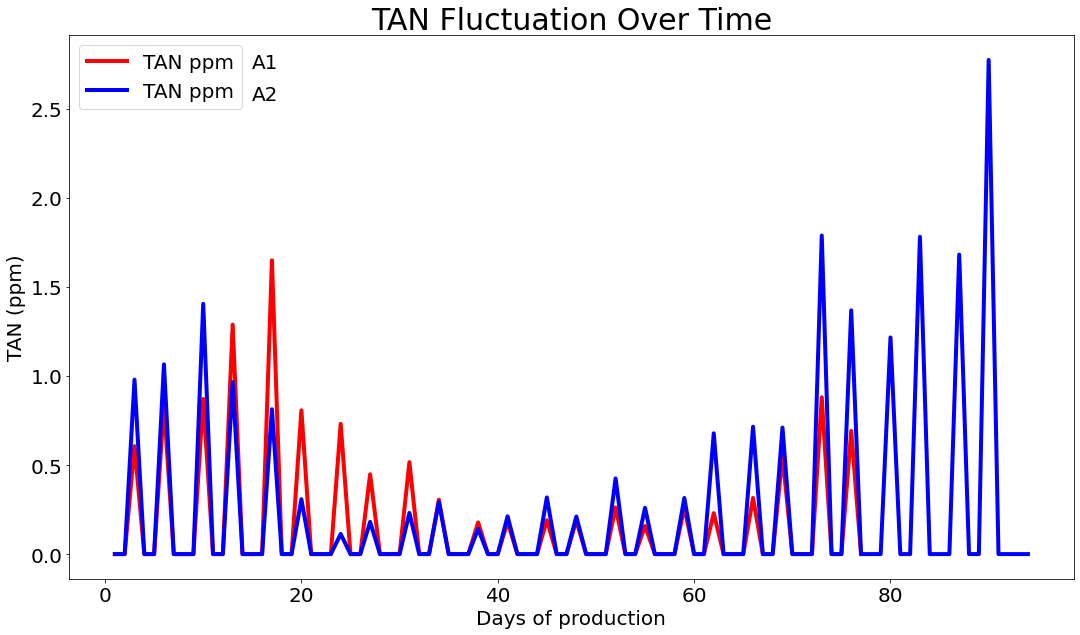

In [ ]:
fig, ax = plt.subplots(figsize=(18,10))
plt.plot('Days of production', 'TAN ppm', data=df_a1 , color='red', linewidth=4)
plt.plot('Days of production', 'TAN ppm', data=df_a2 , color='b', linewidth=4)

#Add some text for labels, title and custom x-axis tick labels, etc.
plt.ylabel('TAN (ppm)', fontsize=20)
plt.xlabel('Days of production',fontsize=20)
ax.set_title('TAN Fluctuation Over Time', fontsize=30)
# ax.set_ylim(ymin=0, ymax=40)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.text(15, 2.73, r'A1', fontsize=20)
plt.text(15, 2.55, r'A2', fontsize=20)
ax.legend(fontsize=20)

Based on the graph above, if we focused on the horizontal red and blue lines -- and ---, they have different length (They indicate all missing values that we replace with zero previosly in the pond A1 & A2). The measurement time of the data collected (TAN) in pond A1 starting passed 2 days, passed 2 days, passed 3 days, passed 2 days, ...., etc till N days. ~ recorded as an arithmetic sequence (2,2,3,2,3,2,..,n). Likewise to the pond A2 with passed day in the end of the measurement time is 4 days (2,2,3,2,3,2,...,4). We know that in the pond A2 has difference data records (94 days of production, while A1 has 77 days of production). That was the reason behind to take action of conducting a consistent time measurement of the data collected.

To understand the factors driving changes in TAN and Phosphate, we would conduct **factor analysis**. The concept behind it is almost the same like **regression analysis**, but we would like to deep dive the factors that are able to explain the relationship between the various independent indicators observed.

Source: [factor analysis](https://en.wikipedia.org/wiki/Factor_analysis) (Wiki)


Further analysis, regarding the missing values on the quality parameters (TAN, Phosphate, Phytoplankton) and water temperature, once we find this case like the prior dataset whom we are processing. For better analysis results, we can handle it by conducting K-Nearest Neighbor model to find the record most similar to the one with a value that is missing and then fill with the most similar record’s value.

# Recommendation
## Shrimp Culture Management
Improved feeds and feeding practices can increase the proportion of nitrogen recovered in shrimp and lessen the amount of ammonia excreted by the culture shrimps.

---

# Acknowledgement

[The author ](mailto:manwarsan@gmail.com) would like to thank to [Aep Pudin](mailto:aeppudin082@gmail.com), an aquaculture specialist from Bogor Agricultural University for brainstorming in this case study.


# References


> Ariadi H., Fadjar M., Mahmudi M., Supriatna. 2019. The relationships between water quality parameters and the growth rate of white shrimp *(Litopenaeus vannamei)* in intensive ponds. AACL Bioflux 12(6):2103-2116.

> Bhatnagar A., Devi P. 2013. Water quality guidelines for the management of pond fish culture. International Journal of Environmental Sciences 3(6):1980-2009.

> Boyd C. E. 2008. Nitrogen a limiting factor in aquaculture production. https://www.globalseafood.org/advocate/nitrogen-a-limiting-factor-in-aquaculture-production/

> Case M., Leca E. E., Leitao S. N., Sant’Anna E. E., Schwamborn R., Junior A. T. D. M. 2008. Plankton community as an indicator of water quality in tropical shrimp culture ponds. Marine Pollution Bulletin 56:1343-1352.

> Edhy W. A., Azhary K., Pribadi J., Chaerudin M. 2010. [White shrimp culture (*Litopenaeus vannamei* Boone, 1931)]. CV. Mulia Indah Jakarta. 194 p.

> Lemonnier H., Courties C., Mugnier C., Torreton J. P., Herbland A. 2010. Nutrient and microbial dynamics in eutrophying shrimp ponds affected or unaffected by vibriosis. Marine Pollution Bulletin 60:402-411.

> Ma Z., Wan R., Song X., Gao L. 2013. The effect of three culture methods on intensive culture system of pacific white shrimp *(Litopenaeus vannamei)*.  J. Ocean Univ. China (Oceanic and Coastal Sea Research) 12:434-440.

> Mingming Z., Yao D.,Li S., Zhang Y., Aweya J.J. 2020. Effects of ammonia on shrimp physiology and immunity: a review. Reviews in Aquaculture 12: 1-18.

> Prapaiwong N., Boyd C. E. 2012. Water temperature in inland, low-salinity shrimp ponds in Alabama. Journal of Applied Aquaculture 24:334-341.

> Wyban J., Walsh W. A., Godin D. M. 1995. Temperature effects on growth, feeding rate and feed conversion of the Pacific white shrimp (*Penaeus vannamei*). Aquaculture 138:267-279.



# Appendix
## Note
The input of TAN and phosphate from feeding increases phytoplankton density. Phytoplankton photosynthesis causes pH to increase, which favors a higher percentage of ammonia. High TAN concentrations can occur in ponds where animals are offered manufactured feeds. Although ammonia seldom kills shrimp, ammonia-nitrogen concentrations above 0.2 mg per liter can stress them and reduce growth. TAN concentrations above 2 mg per liter can result in potentially harmful ammonia levels in warm water. (www.globalseafood.org)


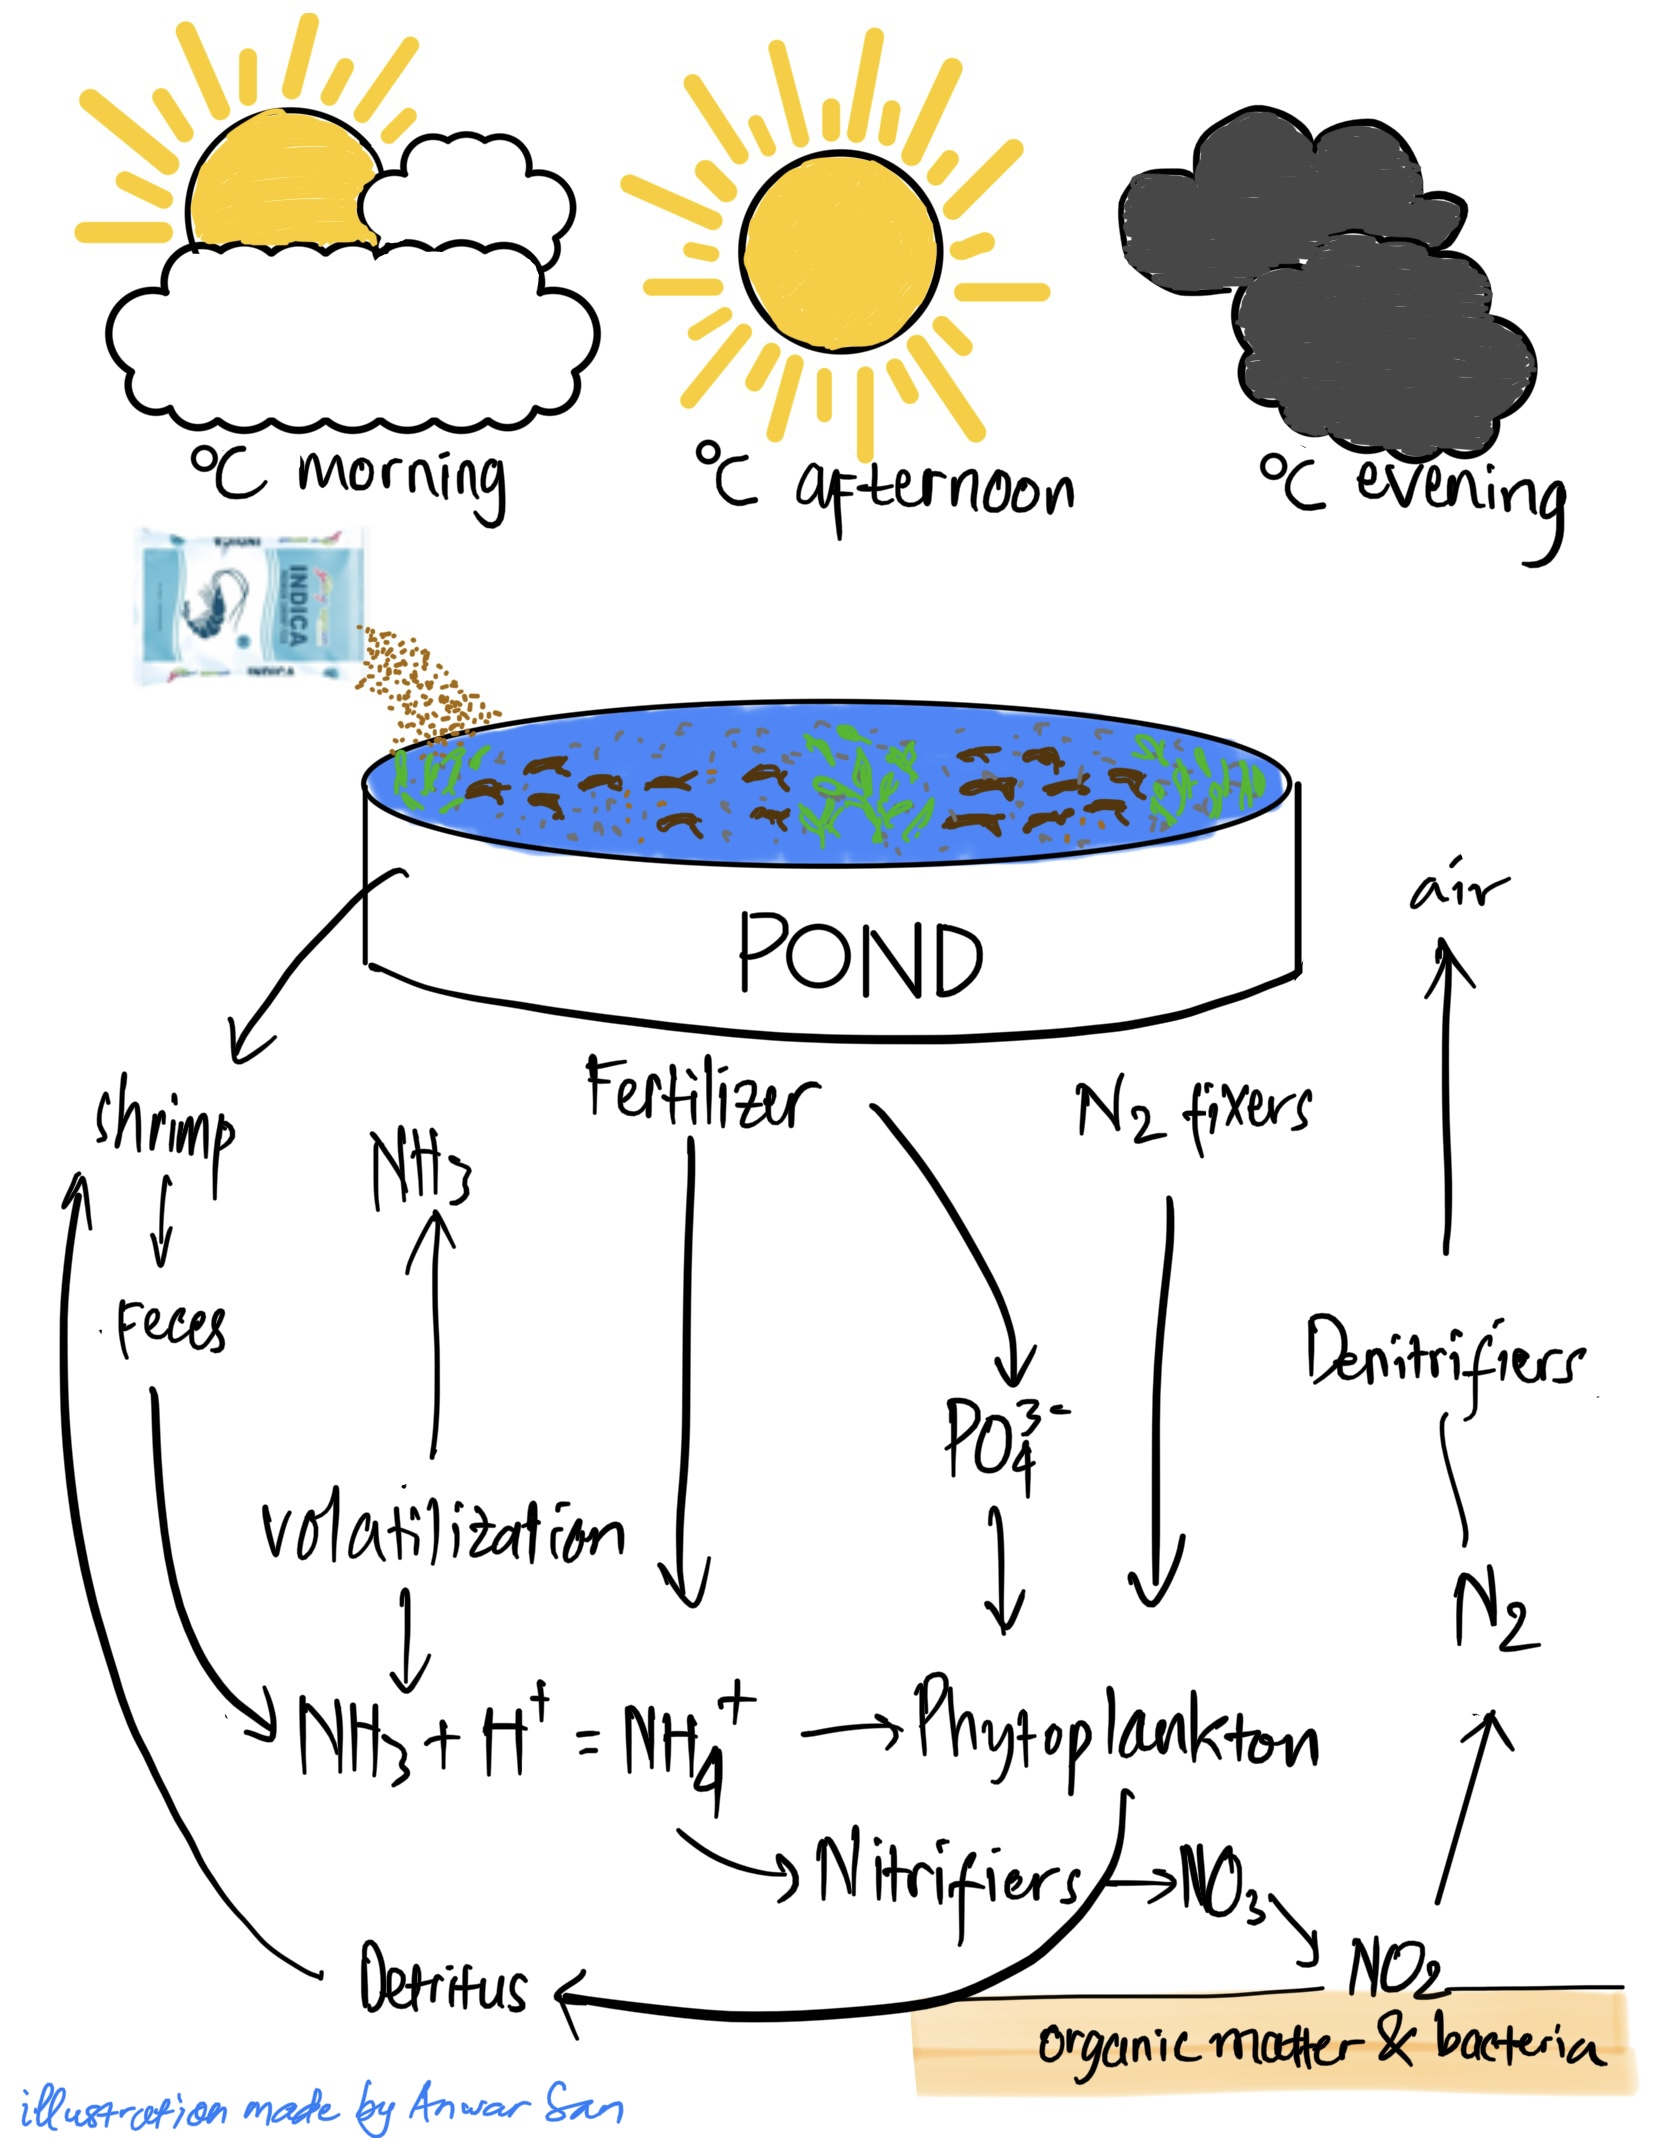

In [ ]:
path = '/content/drive/MyDrive/DELOS/n_cycle.jpg'
img = IPython.display.Image(path, width = 600)
img

*Fig. Nitrogen cycle. Arrows indicate movement of nitrogen in shrimp pond. N2 = nitrogen gas, NO3 = nitrate, NO2 = nitrite, NH3 = nonionized ammonia, NH4 = ammonium, PO4,3- = Phosphate.*

Vast amounts of nitrogen exist in the atmosphere in gaseous form. This nitrogen can be converted to nitrate by lightning, fixed in organic matter by some microorganisms, and converted to nitrogen for fertilizers by an industrial process. Large quantities of nitrogen are found in living organisms and dead organic matter.

Organisms excrete nitrogenous wastes, and when bacteria and other microorganisms decompose dead organic matter, they release ammonia nitrogen into the environment. Ammonia nitrogen consists of non-ionized ammonia (NH3) and ammonium ion (NH4+). Nitrate nitrogen is produced when nitrifying organisms oxidize ammonia nitrogen.

Most plants prefer ammonium ion as a nitrogen source, but can also use nitrate as a nitrogen source. Nitrate can be converted back to nitrogen gas by the activity of denitrifying bacteria.

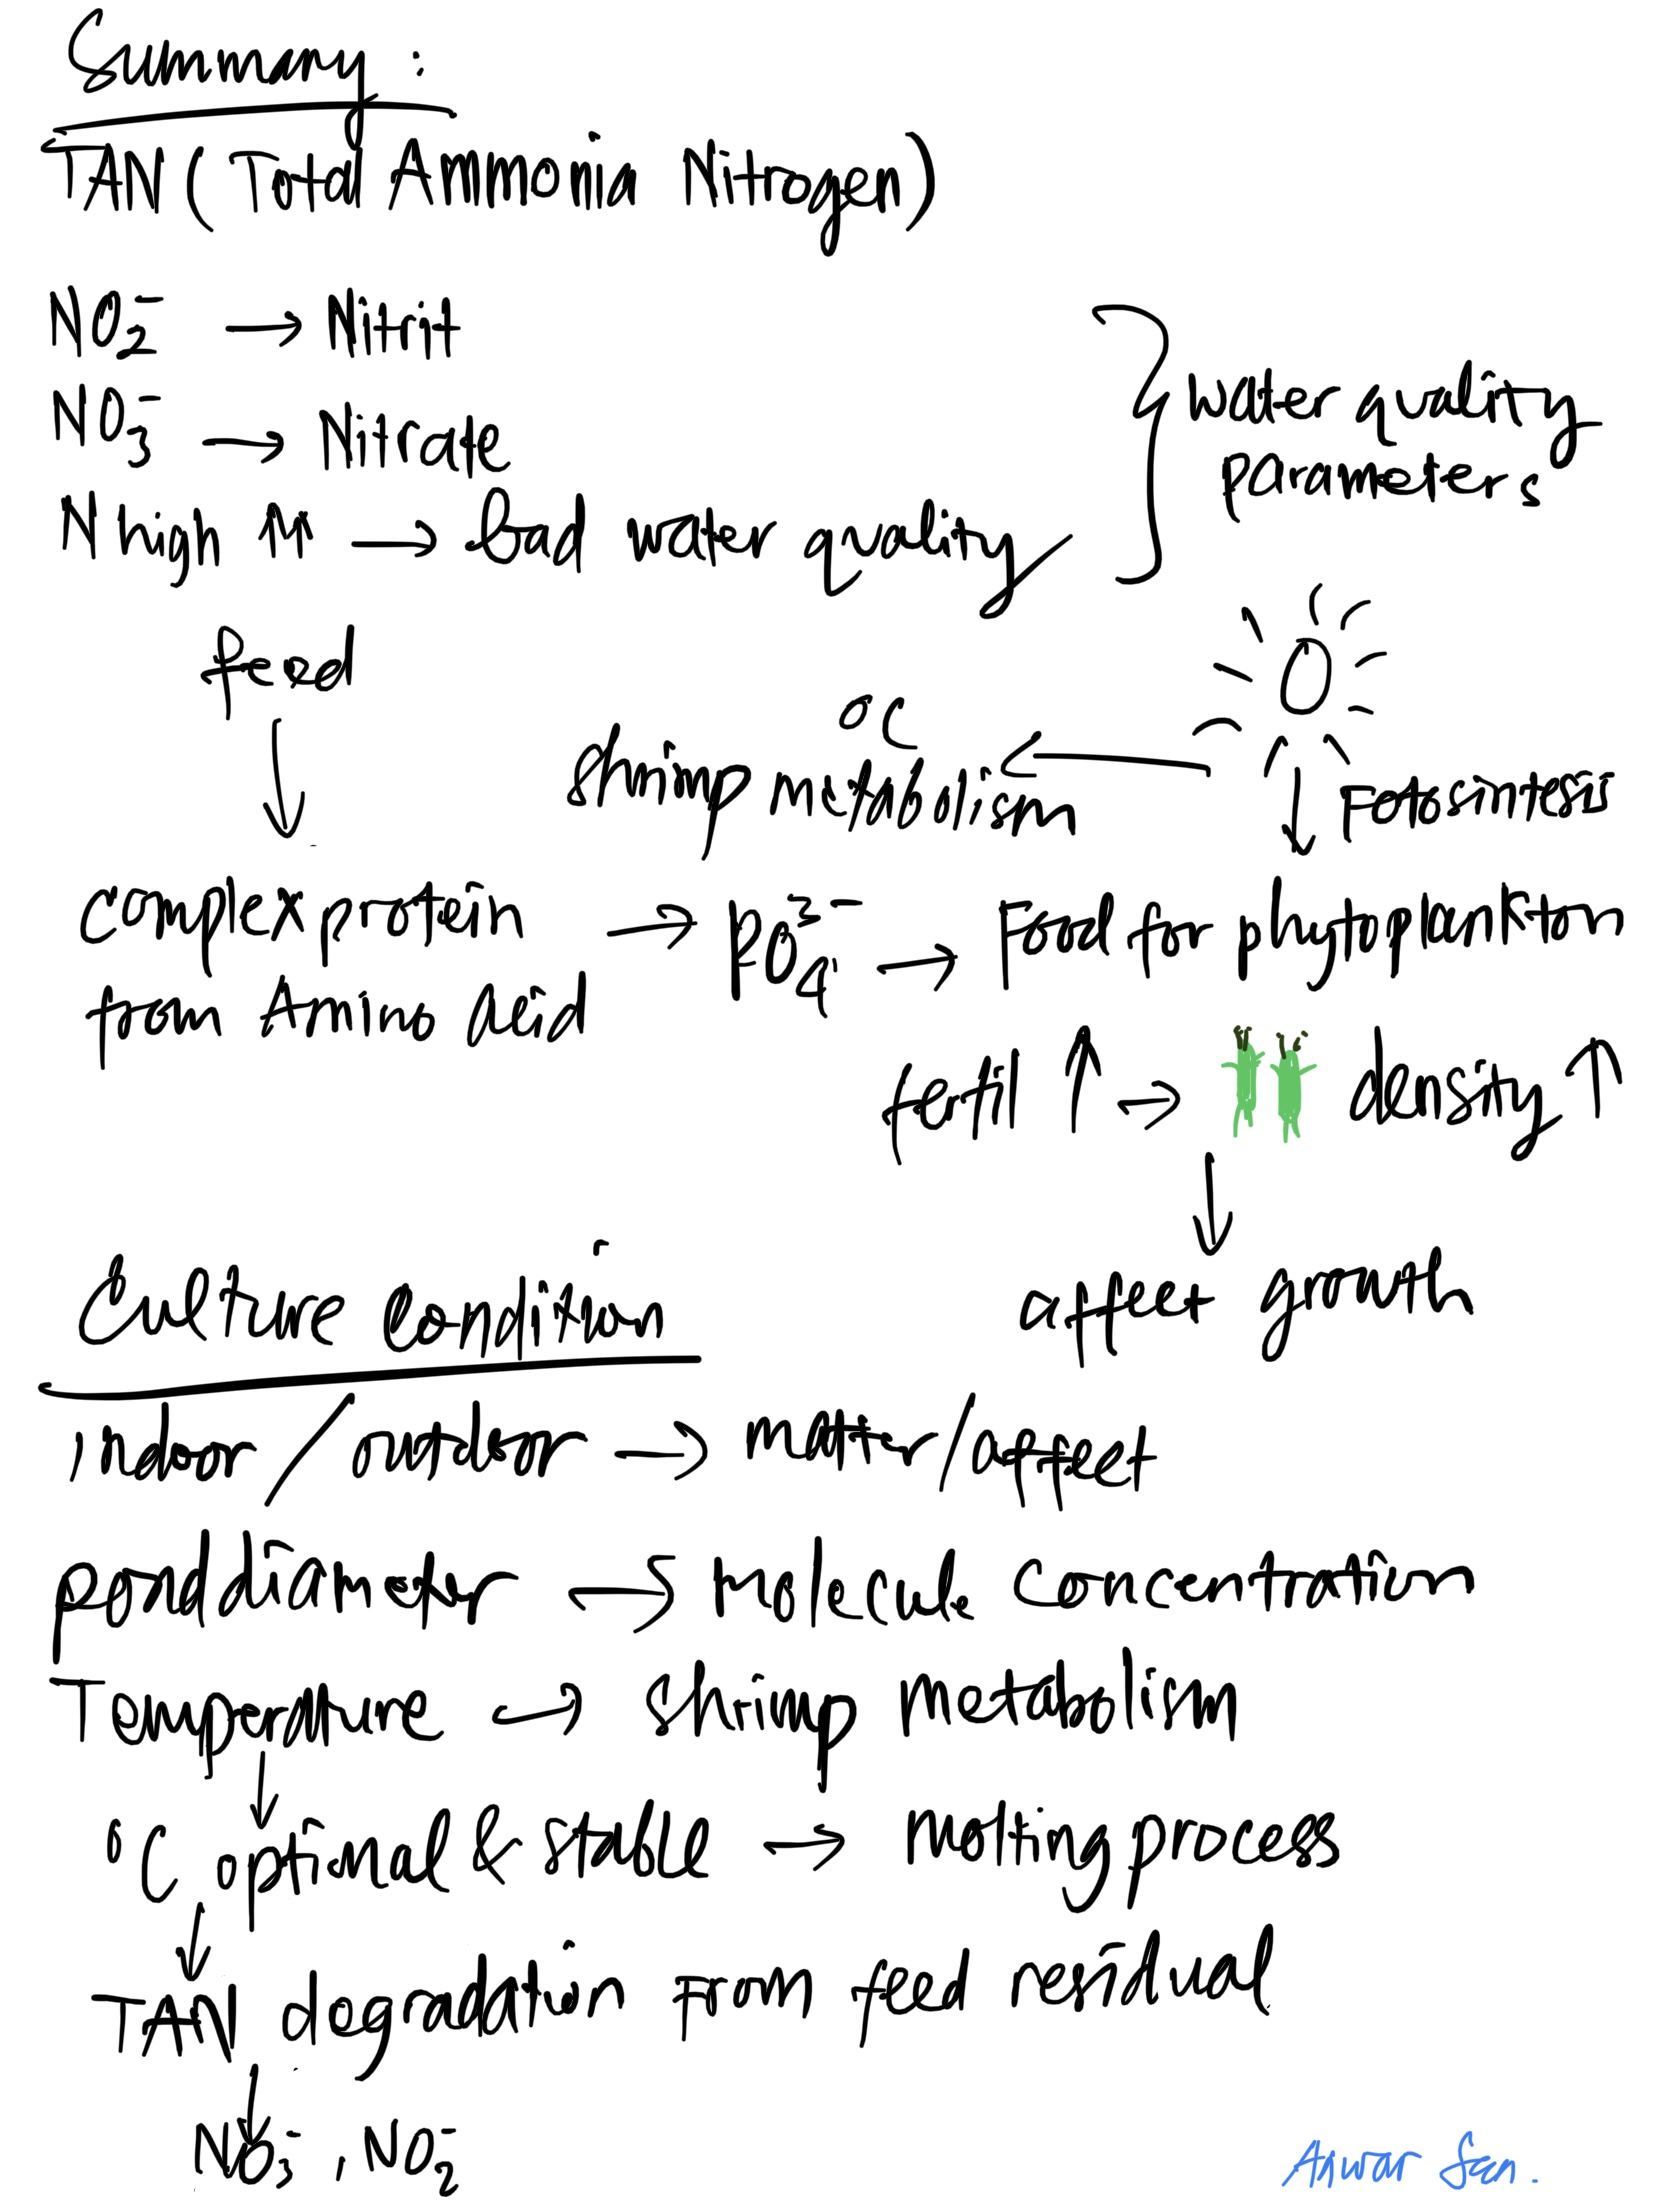

In [ ]:
path = '/content/drive/MyDrive/DELOS/sum.jpg'
img = IPython.display.Image(path, width = 700)
img



Ammonium is absorbed by phytoplankton and other aquatic plants and converted to organic nitrogen in plant tissue. Plant uptake exerts a major control on TAN concentration, but when plants die and decay, ammonia is released. Nitrification, the process by which ammonia nitrogen is oxidized to nitrate by nitrifying bacteria, is an important control on TAN concentration.

Ammonia is a metabolic waste that is potentially toxic to aquatic animals, but ammonium is essentially nontoxic at concentrations encountered in aquaculture systems. Ammonia toxicity is more likely at high feeding rates. The input of TAN and phosphate from feeding increases phytoplankton abundance. Phytoplankton photosynthesis causes pH to increase, which favors a higher percentage of ammonia.

Ammonium is absorbed by phytoplankton and other aquatic plants and converted to organic nitrogen in plant tissue. Plant uptake exerts a major control on TAN concentration, but when plants die and decay, ammonia is released. Nitrification, the process by which ammonia nitrogen is oxidized to nitrate by nitrifying bacteria, is an important control on TAN concentration. For unexplained reasons, nitrite concentration sometimes increases in ponds (Boyd, C.E. 2008).